# MV Oberrhein State Estimation Uncertainty Quantification

## Goal

This notebook compares four uncertainty-quantification paths on the MV Oberrhein medium-voltage network from the [pandapower network library](https://pandapower.readthedocs.io/en/latest/networks/mv_oberrhein.html):

1. analytical UQ with iterative-linear state estimation (ILSE);
2. analytical UQ with Newton–Raphson state estimation (NRSE);
3. Monte Carlo UQ with ILSE; and
4. Monte Carlo UQ with NRSE.

The comparison is repeated for three sensor layouts:

- voltage sensors + current sensors;
- voltage sensors + power sensors; and
- voltage sensors + current sensors + power sensors.

The combined layout places current sensors at every line from-terminal and power sensors at every line to-terminal. This respects PGM's rule that power and current sensors may not share the same terminal of the same branch.


## Setup

The MV Oberrhein input is loaded from the adjacent `data/mv_oberrhein_pgm.json` file. The source network is the [pandapower MV Oberrhein network](https://pandapower.readthedocs.io/en/latest/networks/mv_oberrhein.html), converted with the [Power Grid Model IO pandapower converter](https://power-grid-model-io.readthedocs.io/en/latest/converters/pandapower_converter.html) using the default high-load scenario. The converted operating network is radial with six open sectioning points.

The uncertainty settings are:

- voltage magnitude sigma: 30 V;
- one-sided current magnitude sigma: 1 A;
- current-angle sigma: `1 / 145 * 2π` rad;
- power P sigma: 25 kW; and
- power Q sigma: 10 kvar.

Monte Carlo updates are generated with PGM's public-coordinate helper and a fixed seed.


In [1]:
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import power_grid_model
from power_grid_model import (
    AngleMeasurementType,
    AttributeType,
    CalculationMethod,
    CalculationType,
    ComponentType,
    DatasetType,
    MeasuredTerminalType,
    PowerGridModel,
    initialize_array,
)
from power_grid_model._core.power_grid_model_c.get_pgm_dll_path import get_pgm_dll_path
from power_grid_model.utils import create_state_estimation_monte_carlo_updates
from power_grid_model.validation import assert_valid_input_data

output_directory = Path("docs/examples/output/mv_oberrhein") if Path("docs/examples").is_dir() else Path("output/mv_oberrhein")
output_directory.mkdir(parents=True, exist_ok=True)

print("Python:", sys.executable)
print("Power Grid Model package:", power_grid_model.__file__)
print("Native library:", get_pgm_dll_path())

Python: /home/jhe/pgm_dev/power-grid-model/.venv/bin/python
Power Grid Model package: /home/jhe/pgm_dev/power-grid-model/src/power_grid_model/__init__.py
Native library: /home/jhe/pgm_dev/power-grid-model/build/bin/libpower_grid_model_c.so


In [2]:
# ruff: noqa: E501
import json

data_file_candidates = [
    Path("data/mv_oberrhein_pgm.json"),
    Path("docs/examples/data/mv_oberrhein_pgm.json"),
]
data_file = next((path for path in data_file_candidates if path.exists()), None)
if data_file is None:
    raise FileNotFoundError(
        "Could not find mv_oberrhein_pgm.json. Run this notebook from the repository root "
        "or from docs/examples."
    )
with data_file.open() as file:
    workshop_model = json.load(file)

def deserialize_workshop_model(component_rows):
    input_data = {}
    for component_name, rows in component_rows.items():
        component = ComponentType(component_name)
        array = initialize_array(DatasetType.input, component, len(rows))
        common_fields = set(rows[0]).intersection(array.dtype.names)
        for row in rows[1:]:
            common_fields.intersection_update(row)
        for field in sorted(common_fields):
            array[field] = [row[field] for row in rows]
        input_data[component] = array
    return input_data


base_input_data = deserialize_workshop_model(workshop_model)
assert_valid_input_data(
    base_input_data,
    calculation_type=CalculationType.power_flow,
    symmetric=True,
)
print({str(component): len(values) for component, values in base_input_data.items()})


{'node': 179, 'line': 181, 'source': 2, 'sym_load': 441, 'transformer': 2, 'sym_gen': 153}


## MV Oberrhein topology

The topology figure is generated from the converted MV Oberrhein model and saved alongside the UQ figures. The network contains **179 buses (nodes), 181 lines, and 2 transformers**. The default pandapower high-load scenario operates the meshed network radially using six open sectioning lines:

<img src="output/mv_oberrhein/figures/mv_oberrhein_topology.png" alt="MV Oberrhein network topology" width="900" />

| PGM line | Endpoints | Terminal status |
|---:|:---:|:---|
| **187** | **102–77** | <span style="color:#b42318"><strong>OPEN</strong> (from_status=1, to_status=0)</span> |
| **199** | **120–79** | <span style="color:#b42318"><strong>OPEN</strong> (from_status=1, to_status=0)</span> |
| **207** | **11–117** | <span style="color:#b42318"><strong>OPEN</strong> (from_status=1, to_status=0)</span> |
| **241** | **34–92** | <span style="color:#b42318"><strong>OPEN</strong> (from_status=1, to_status=0)</span> |
| **261** | **141–135** | <span style="color:#b42318"><strong>OPEN</strong> (from_status=1, to_status=0)</span> |
| **354** | **15–25** | <span style="color:#b42318"><strong>OPEN</strong> (from_status=1, to_status=0)</span> |



In [3]:
# ruff: noqa: E501
# Verify and display the open sectioning lines that keep the MV Oberrhein network radial.
topology_control_line_ids = [
    int(row[AttributeType.id])
    for row in base_input_data[ComponentType.line]
    if not (int(row[AttributeType.from_status]) and int(row[AttributeType.to_status]))
]
line_rows = {
    int(row[AttributeType.id]): row
    for row in base_input_data[ComponentType.line]
}
topology_control_lines = pd.DataFrame(
    [
        {
            "line": line_id,
            "endpoints": f"{int(line_rows[line_id][AttributeType.from_node])}-{int(line_rows[line_id][AttributeType.to_node])}",
            "from_status": int(line_rows[line_id][AttributeType.from_status]),
            "to_status": int(line_rows[line_id][AttributeType.to_status]),
            "switch status": "OPEN",
        }
        for line_id in topology_control_line_ids
    ]
)
expected_to_status = {line_id: 0 for line_id in topology_control_line_ids}
actual_to_status = {
    line_id: int(line_rows[line_id][AttributeType.to_status])
    for line_id in topology_control_line_ids
}
if actual_to_status != expected_to_status:
    raise ValueError(f"Unexpected topology-control statuses: {actual_to_status}")

def highlight_switch_status(column):
    return [
        "background-color: #d9f2e3; color: #166534; font-weight: bold"
        if value == "CLOSED"
        else "background-color: #fde2e1; color: #991b1b; font-weight: bold"
        for value in column
    ]

topology_control_lines.style.apply(highlight_switch_status, subset=["switch status"])


,line,endpoints,from_status,to_status,switch status
0,187,102-77,1,0,OPEN
1,199,120-79,1,0,OPEN
2,207,11-117,1,0,OPEN
3,241,34-92,1,0,OPEN
4,261,141-135,1,0,OPEN
5,354,15-25,1,0,OPEN


## Build the three sensor layouts

All layouts use the same power-flow operating point to generate noisy measurements. The current phasor is reconstructed from the three-phase power-flow branch power and line-to-line terminal voltage using `I = (S / (√3 U))*`.

In [4]:
# ruff: noqa: E501
voltage_sensor_ids = np.array([0, 1, 63, 109])
voltage_sigma = 30.0
voltage_angle_sigma = voltage_sigma / 20_000.0 * 2.0 * np.pi
current_sigma = 1.0
current_angle_sigma = current_sigma / 145.0 * 2.0 * np.pi
power_p_sigma = 25_000.0
power_q_sigma = 10_000.0
sensor_seed = 42


def max_component_id(input_data):
    return max(int(np.max(values[AttributeType.id])) for values in input_data.values())


def make_sensor_input(sensor_setting, seed=sensor_seed):
    input_data = {component: values.copy() for component, values in base_input_data.items()}
    power_flow = PowerGridModel(input_data, system_frequency=50.0).calculate_power_flow(
        symmetric=True,
        calculation_method=CalculationMethod.newton_raphson,
        error_tolerance=1e-8,
        max_iterations=50,
    )
    rng = np.random.default_rng(seed)
    node_ids = input_data[ComponentType.node][AttributeType.id]
    node_index = {int(node_id): index for index, node_id in enumerate(node_ids)}
    voltage_index = np.array([node_index[int(node_id)] for node_id in voltage_sensor_ids])
    line = input_data[ComponentType.line]
    line_ids = line[AttributeType.id]
    line_from_index = np.array([node_index[int(node_id)] for node_id in line[AttributeType.from_node]])

    max_id = max_component_id(input_data)
    voltage_sensor = initialize_array(DatasetType.input, ComponentType.sym_voltage_sensor, len(voltage_sensor_ids))
    voltage_sensor[AttributeType.id] = np.arange(max_id + 1, max_id + 1 + len(voltage_sensor_ids))
    voltage_sensor[AttributeType.measured_object] = voltage_sensor_ids
    voltage_sensor[AttributeType.u_sigma] = voltage_sigma
    voltage_sensor[AttributeType.u_measured] = (
        power_flow[ComponentType.node][AttributeType.u][voltage_index]
        + rng.normal(0.0, voltage_sigma, len(voltage_sensor_ids))
    )
    voltage_sensor[AttributeType.u_angle_measured] = (
        power_flow[ComponentType.node][AttributeType.u_angle][voltage_index]
        + rng.normal(0.0, voltage_angle_sigma, len(voltage_sensor_ids))
    )
    max_id += len(voltage_sensor_ids)

    u_from = (
        power_flow[ComponentType.node][AttributeType.u][line_from_index]
        * np.exp(1j * power_flow[ComponentType.node][AttributeType.u_angle][line_from_index])
    )
    s_from = power_flow[ComponentType.line][AttributeType.p_from] + 1j * power_flow[ComponentType.line][AttributeType.q_from]
    i_from = np.conj(s_from / (np.sqrt(3.0) * u_from))
    np.testing.assert_allclose(np.abs(i_from), power_flow[ComponentType.line][AttributeType.i_from], rtol=1e-6, atol=1e-8)

    sensors = input_data | {ComponentType.sym_voltage_sensor: voltage_sensor}
    if sensor_setting in {"voltage + current", "voltage + current + power"}:
        current_count = len(line_ids)
        current_sensor = initialize_array(DatasetType.input, ComponentType.sym_current_sensor, current_count)
        current_sensor[AttributeType.id] = np.arange(max_id + 1, max_id + 1 + current_count)
        current_sensor[AttributeType.measured_object] = line_ids
        current_sensor[AttributeType.measured_terminal_type] = MeasuredTerminalType.branch_from
        current_sensor[AttributeType.angle_measurement_type] = AngleMeasurementType.global_angle
        current_sensor[AttributeType.i_sigma] = current_sigma
        current_sensor[AttributeType.i_angle_sigma] = current_angle_sigma
        current_sensor[AttributeType.i_measured] = np.abs(i_from) + rng.normal(0.0, current_sigma, current_count)
        current_sensor[AttributeType.i_angle_measured] = np.angle(i_from) + rng.normal(0.0, current_angle_sigma, current_count)
        sensors[ComponentType.sym_current_sensor] = current_sensor
        max_id += current_count

    if sensor_setting in {"voltage + power", "voltage + current + power"}:
        power_count = len(line_ids)
        power_sensor = initialize_array(DatasetType.input, ComponentType.sym_power_sensor, power_count)
        power_sensor[AttributeType.id] = np.arange(max_id + 1, max_id + 1 + power_count)
        power_sensor[AttributeType.measured_object] = line_ids
        power_sensor[AttributeType.measured_terminal_type] = MeasuredTerminalType.branch_to
        power_sensor[AttributeType.p_sigma] = power_p_sigma
        power_sensor[AttributeType.q_sigma] = power_q_sigma
        power_sensor[AttributeType.p_measured] = (
            power_flow[ComponentType.line][AttributeType.p_to]
            + rng.normal(0.0, power_p_sigma, power_count)
        )
        power_sensor[AttributeType.q_measured] = (
            power_flow[ComponentType.line][AttributeType.q_to]
            + rng.normal(0.0, power_q_sigma, power_count)
        )
        sensors[ComponentType.sym_power_sensor] = power_sensor

    assert_valid_input_data(
        sensors,
        calculation_type=CalculationType.state_estimation,
        symmetric=True,
    )
    return sensors


sensor_settings = [
    "voltage + current",
    "voltage + power",
    "voltage + current + power",
]
state_estimation_inputs = {setting: make_sensor_input(setting) for setting in sensor_settings}
pd.DataFrame(
    {
        "sensor setting": sensor_settings,
        "voltage sensors": [len(state_estimation_inputs[s][ComponentType.sym_voltage_sensor]) for s in sensor_settings],
        "current sensors": [len(state_estimation_inputs[s].get(ComponentType.sym_current_sensor, [])) for s in sensor_settings],
        "power sensors": [len(state_estimation_inputs[s].get(ComponentType.sym_power_sensor, [])) for s in sensor_settings],
    }
)

,sensor setting,voltage sensors,current sensors,power sensors
0,voltage + current,4,181,0
1,voltage + power,4,0,181
2,voltage + current + power,4,181,181


## Analytical UQ: ILSE and NRSE

The point estimates and analytical output sigmas are computed from identical sensor inputs. The checks confirm that requesting analytical UQ does not alter the point estimate.

In [5]:
methods = {
    "Analytical ILSE": CalculationMethod.iterative_linear,
    "Analytical NRSE": CalculationMethod.newton_raphson,
}
analytical_results = {}
analytical_seconds = {}
deterministic_seconds = {}

for setting, input_data in state_estimation_inputs.items():
    for method_name, calculation_method in methods.items():
        model = PowerGridModel(input_data, system_frequency=50.0)
        start = perf_counter()
        without_uq = model.calculate_state_estimation(
            calculation_method=calculation_method,
            error_tolerance=1e-10,
            max_iterations=50,
        )
        deterministic_seconds[setting, method_name] = perf_counter() - start
        start = perf_counter()
        with_uq = model.calculate_state_estimation(
            calculation_method=calculation_method,
            calculate_uncertainty=True,
            error_tolerance=1e-10,
            max_iterations=50,
        )
        analytical_seconds[setting, method_name] = perf_counter() - start
        for component in (ComponentType.node, ComponentType.line):
            for field in ("u", "u_angle", "p", "q", "i_from", "i_to"):
                if field in with_uq[component].dtype.names:
                    np.testing.assert_allclose(with_uq[component][field], without_uq[component][field])
        analytical_results[setting, method_name] = with_uq

pd.DataFrame(
    [
        {"sensor setting": setting, "method": method, "analytical time [s]": analytical_seconds[setting, method]}
        for setting in sensor_settings
        for method in methods
    ]
).round(3)

,sensor setting,method,analytical time [s]
0,voltage + current,Analytical ILSE,0.002
1,voltage + current,Analytical NRSE,0.003
2,voltage + power,Analytical ILSE,0.002
3,voltage + power,Analytical NRSE,0.003
4,voltage + current + power,Analytical ILSE,0.002
5,voltage + current + power,Analytical NRSE,0.003


## Monte Carlo UQ: ILSE and NRSE

The same noisy update batch is used for both state-estimation methods within each sensor setting. Failed batch scenarios are excluded from empirical standard deviations and reported explicitly.

In [6]:
monte_carlo_sample_count = 1_000
monte_carlo_results = {}
monte_carlo_valid = {}
monte_carlo_seconds = {}
benchmark_rows = []

for setting, input_data in state_estimation_inputs.items():
    updates = create_state_estimation_monte_carlo_updates(
        input_data,
        monte_carlo_sample_count,
        seed=2026,
    )
    for method_name, calculation_method in methods.items():
        model = PowerGridModel(input_data, system_frequency=50.0)
        start = perf_counter()
        batch_result = model.calculate_state_estimation(
            calculation_method=calculation_method,
            update_data=updates,
            error_tolerance=1e-8,
            max_iterations=50,
            continue_on_batch_error=True,
        )
        elapsed = perf_counter() - start
        failed = [] if model.batch_error is None else model.batch_error.failed_scenarios
        valid = np.ones(monte_carlo_sample_count, dtype=bool)
        valid[failed] = False
        np.testing.assert_array_less(0.90 * monte_carlo_sample_count, np.count_nonzero(valid))
        monte_carlo_results[setting, method_name] = batch_result
        monte_carlo_valid[setting, method_name] = valid
        monte_carlo_seconds[setting, method_name] = elapsed
        benchmark_rows.append(
            {
                "sensor setting": setting,
                "method": method_name.replace("Analytical", "Monte Carlo"),
                "Monte Carlo time [s]": elapsed,
                "attempted samples": monte_carlo_sample_count,
                "converged samples": int(np.count_nonzero(valid)),
                "time [ms / attempted sample]": 1e3 * elapsed / monte_carlo_sample_count,
            }
        )

monte_carlo_timing_sample_counts = [10, 100, 500, 2_000, 5_000, 10_000]
monte_carlo_scaling_seconds = {}
for setting, input_data in state_estimation_inputs.items():
    for sample_count in monte_carlo_timing_sample_counts:
        updates = create_state_estimation_monte_carlo_updates(
            input_data,
            sample_count,
            seed=2026,
        )
        for method_name, calculation_method in methods.items():
            model = PowerGridModel(input_data, system_frequency=50.0)
            start = perf_counter()
            model.calculate_state_estimation(
                calculation_method=calculation_method,
                update_data=updates,
                error_tolerance=1e-8,
                max_iterations=50,
                continue_on_batch_error=True,
            )
            monte_carlo_scaling_seconds[setting, method_name, sample_count] = perf_counter() - start

pd.DataFrame(benchmark_rows).round(3)

,sensor setting,method,Monte Carlo time [s],attempted samples,converged samples,time [ms / attempted sample]
0,voltage + current,Monte Carlo ILSE,0.253,1000,1000,0.253
1,voltage + current,Monte Carlo NRSE,0.412,1000,1000,0.412
2,voltage + power,Monte Carlo ILSE,0.254,1000,1000,0.254
3,voltage + power,Monte Carlo NRSE,0.391,1000,1000,0.391
4,voltage + current + power,Monte Carlo ILSE,0.299,1000,1000,0.299
5,voltage + current + power,Monte Carlo NRSE,0.450,1000,1000,0.450


## Four-way comparison

The table reports output standard deviations for representative MV Oberrhein quantities. Analytical columns are PGM's propagated sigmas; Monte Carlo columns are sample standard deviations over converged scenarios. Units are SI, with voltage angles in radians.

In [7]:
node_ids = base_input_data[ComponentType.node][AttributeType.id].astype(int)
line_ids = base_input_data[ComponentType.line][AttributeType.id].astype(int)

output_specs = []
for index, node_id in enumerate(node_ids):
    for quantity, value_field, sigma_field, unit in [
        ("voltage magnitude", "u", "u_sigma", "V"),
        ("voltage angle", "u_angle", "u_angle_sigma", "rad"),
        ("active power injection", "p", "p_sigma", "W"),
        ("reactive power injection", "q", "q_sigma", "var"),
    ]:
        output_specs.append(
            {
                "component": "node",
                "id": int(node_id),
                "terminal": "—",
                "quantity": quantity,
                "component_type": ComponentType.node,
                "value_field": value_field,
                "sigma_field": sigma_field,
                "index": index,
                "unit": unit,
            }
        )

for index, line_id in enumerate(line_ids):
    for terminal, value_suffix in [("from", "from"), ("to", "to")]:
        for quantity, field_prefix, unit in [
            ("current", "i", "A"),
            ("active power", "p", "W"),
            ("reactive power", "q", "var"),
        ]:
            output_specs.append(
                {
                    "component": "line",
                    "id": int(line_id),
                    "terminal": terminal,
                    "quantity": quantity,
                    "component_type": ComponentType.line,
                    "value_field": f"{field_prefix}_{value_suffix}",
                    "sigma_field": f"{field_prefix}_{value_suffix}_sigma",
                    "index": index,
                    "unit": unit,
                }
            )

comparison_rows = []
for setting in sensor_settings:
    for spec in output_specs:
        row = {
            "sensor setting": setting,
            "component": spec["component"],
            "id": spec["id"],
            "terminal": spec["terminal"],
            "quantity": spec["quantity"],
            "unit": spec["unit"],
        }
        for method_name in methods:
            analytical = analytical_results[setting, method_name][spec["component_type"]][spec["sigma_field"]][spec["index"]]
            valid = monte_carlo_valid[setting, method_name]
            sampled = monte_carlo_results[setting, method_name][spec["component_type"]][spec["value_field"]][valid, spec["index"]]
            row[f"{method_name} sigma"] = float(analytical)
            row[f"Monte Carlo {method_name.split()[-1]} sigma"] = float(np.std(sampled, ddof=1))
        comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows)
numeric_columns = [
    "Analytical ILSE sigma",
    "Monte Carlo ILSE sigma",
    "Analytical NRSE sigma",
    "Monte Carlo NRSE sigma",
]
np.testing.assert_array_equal(
    np.isinf(comparison[numeric_columns].to_numpy()),
    np.zeros_like(comparison[numeric_columns].to_numpy(), dtype=bool),
)
comparison = comparison[
    ["sensor setting", "component", "id", "terminal", "quantity", "unit", *numeric_columns]
]
comparison_file = output_directory / "mv_oberrhein_uq_comparison.csv"
comparison.to_csv(comparison_file, index=False)
print(f"Comparison table exported to {comparison_file}")

Comparison table exported to output/mv_oberrhein/mv_oberrhein_uq_comparison.csv


## Network-wide comparison figures

The complete 5,406-row comparison is exported to `output/mv_oberrhein/mv_oberrhein_uq_comparison.csv` and is not rendered in the notebook. The node-voltage, branch-current, and branch-active-power bar charts are split into 30-element chunks per sensor layout so that the IDs and method bars remain readable. Each node or line has four bars for the four UQ methods; the exported table retains voltage angle, reactive power, and both line terminals. The final figure compares the four baseline UQ timings and Monte Carlo ILSE/NRSE scaling at 100, 500, 2,000, 5,000, and 10,000 samples across the three sensor settings.

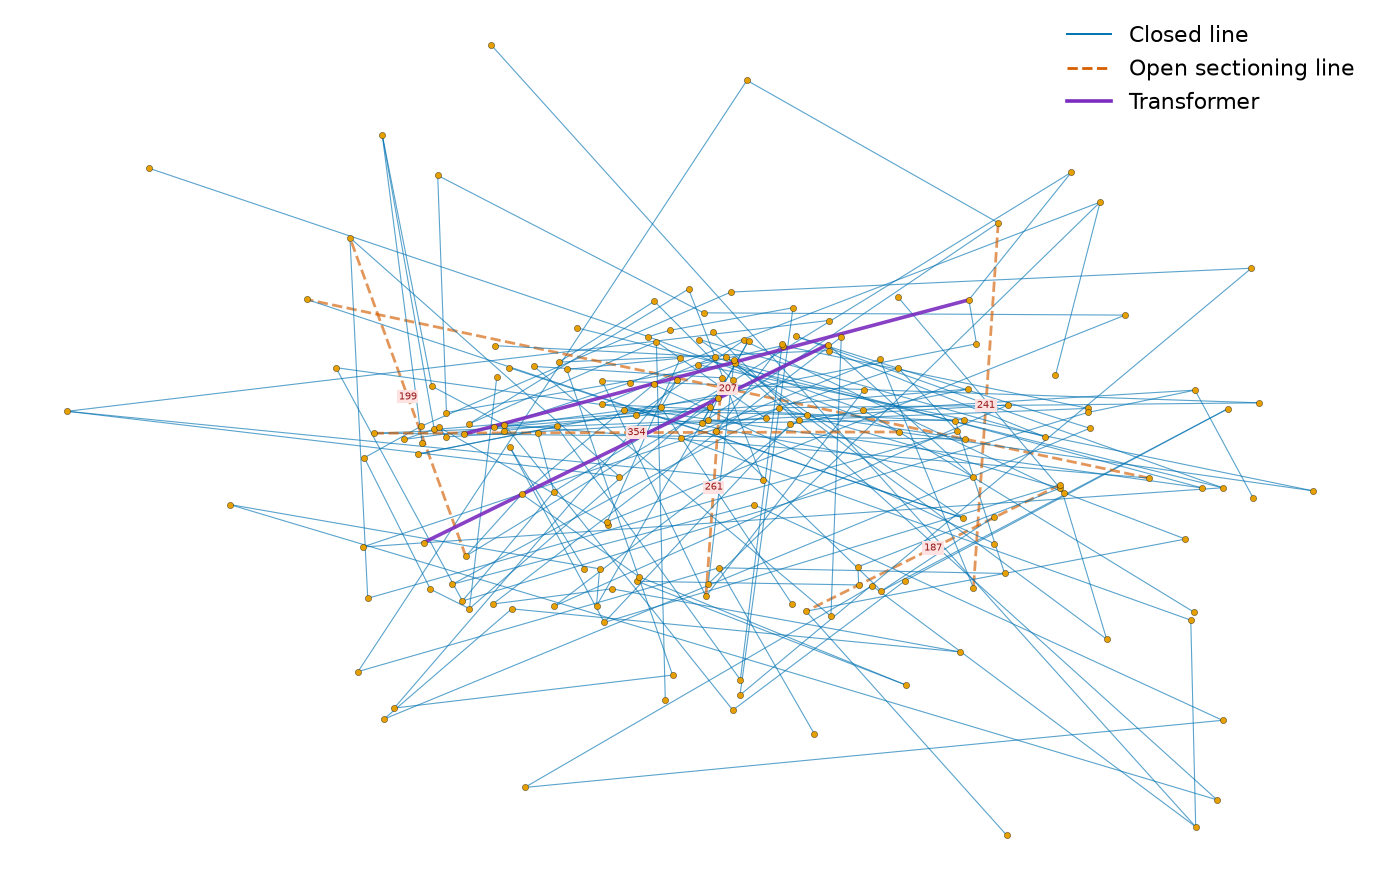

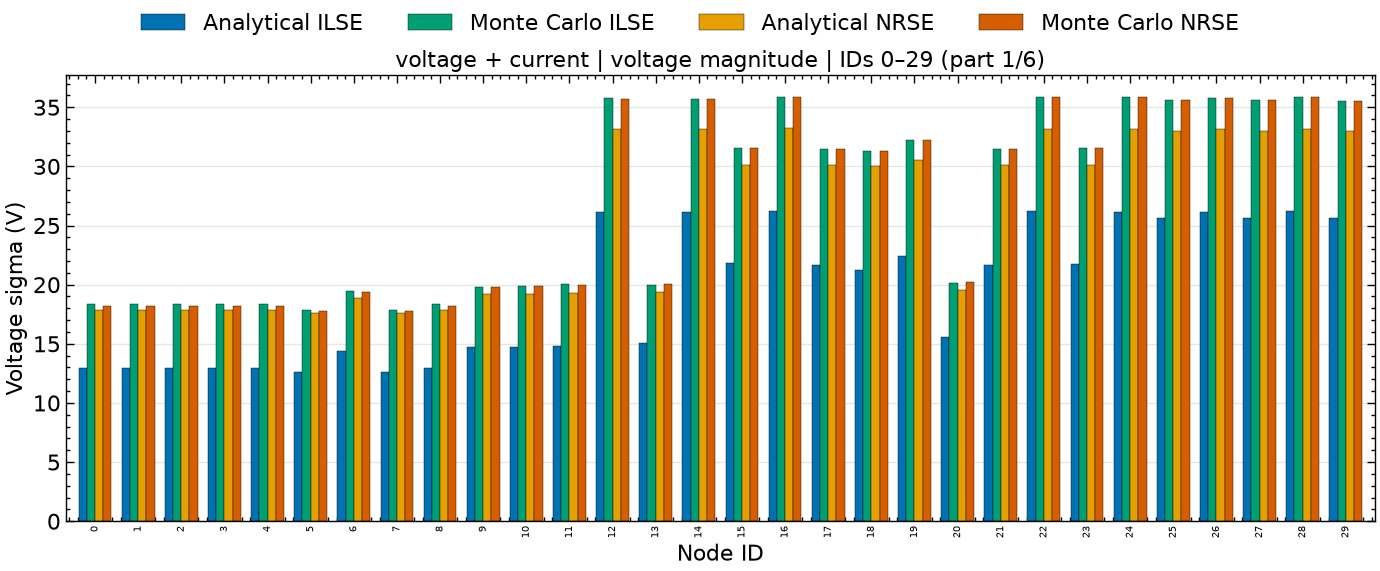

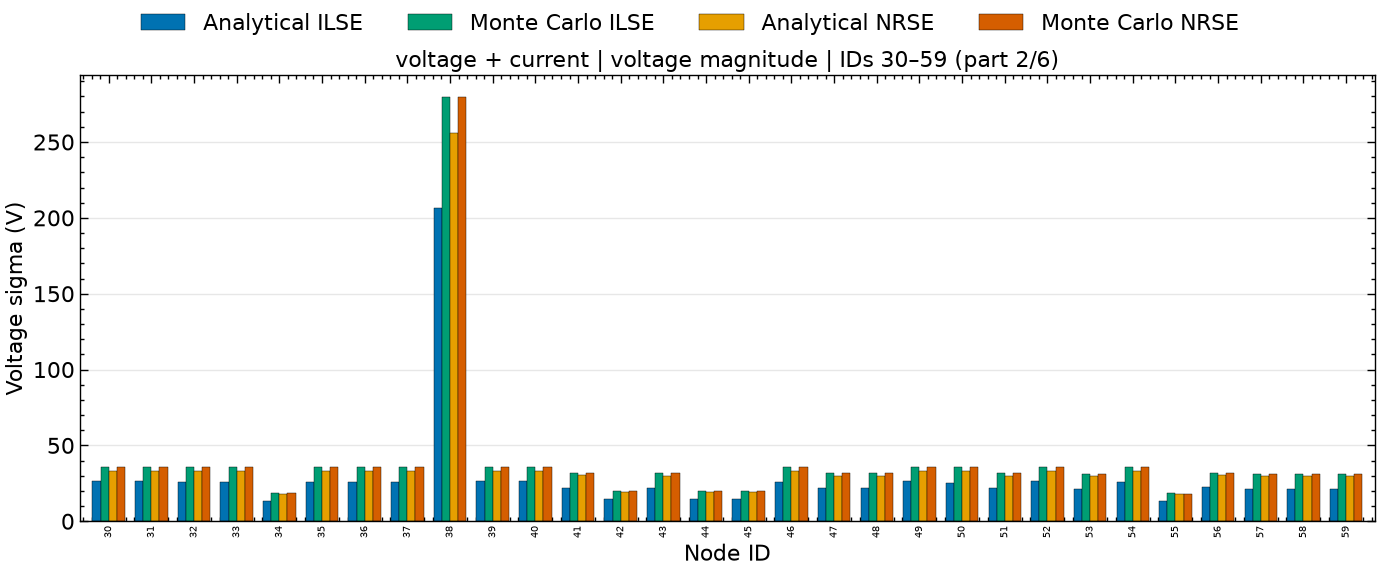

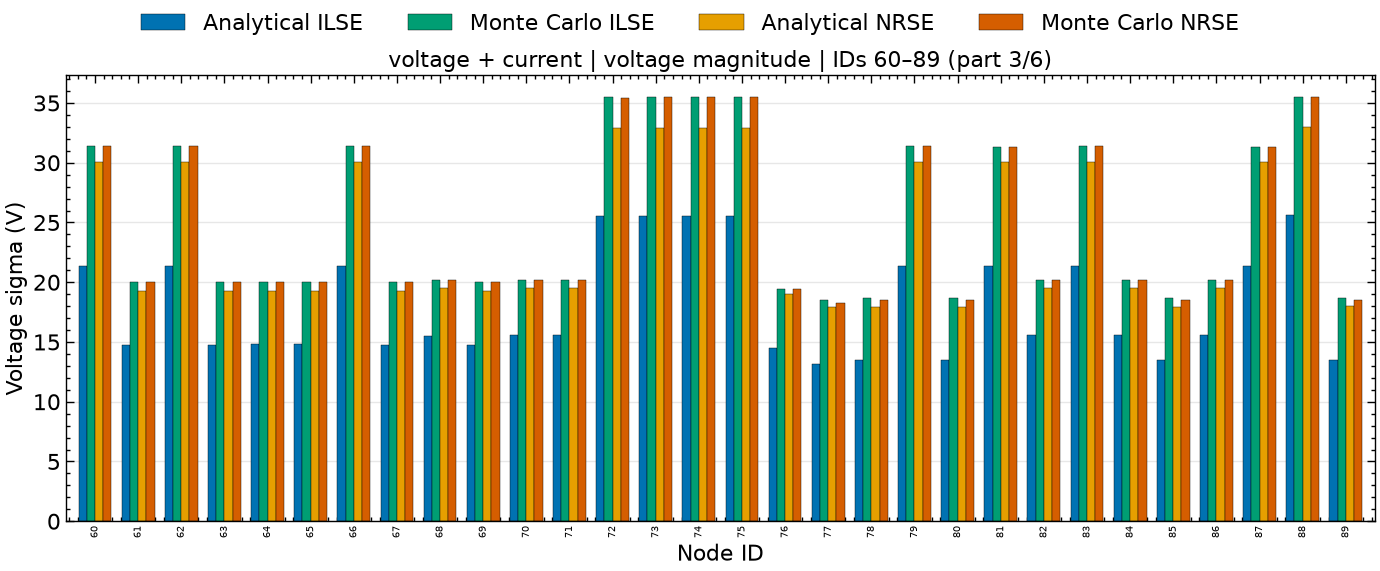

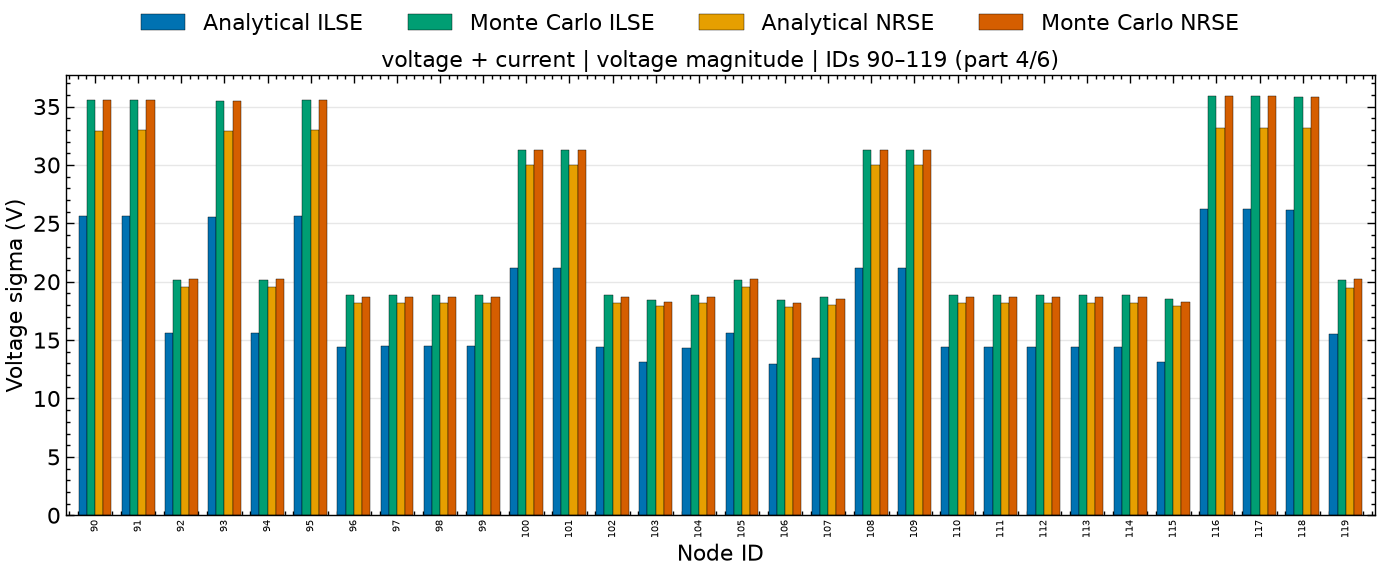

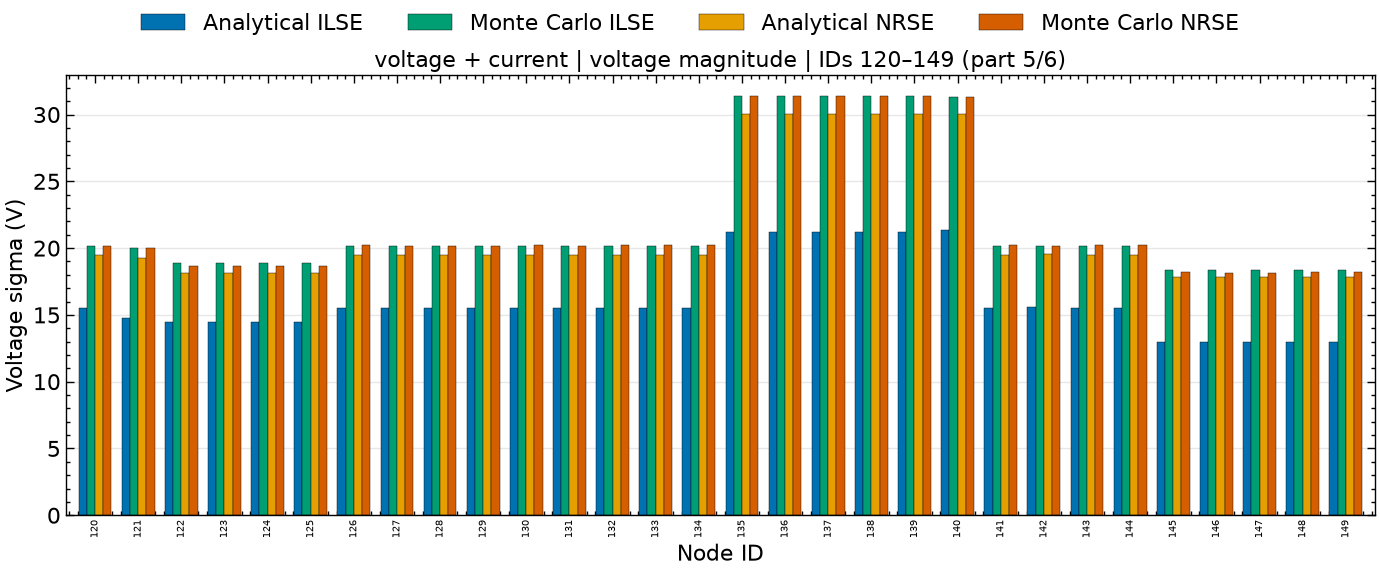

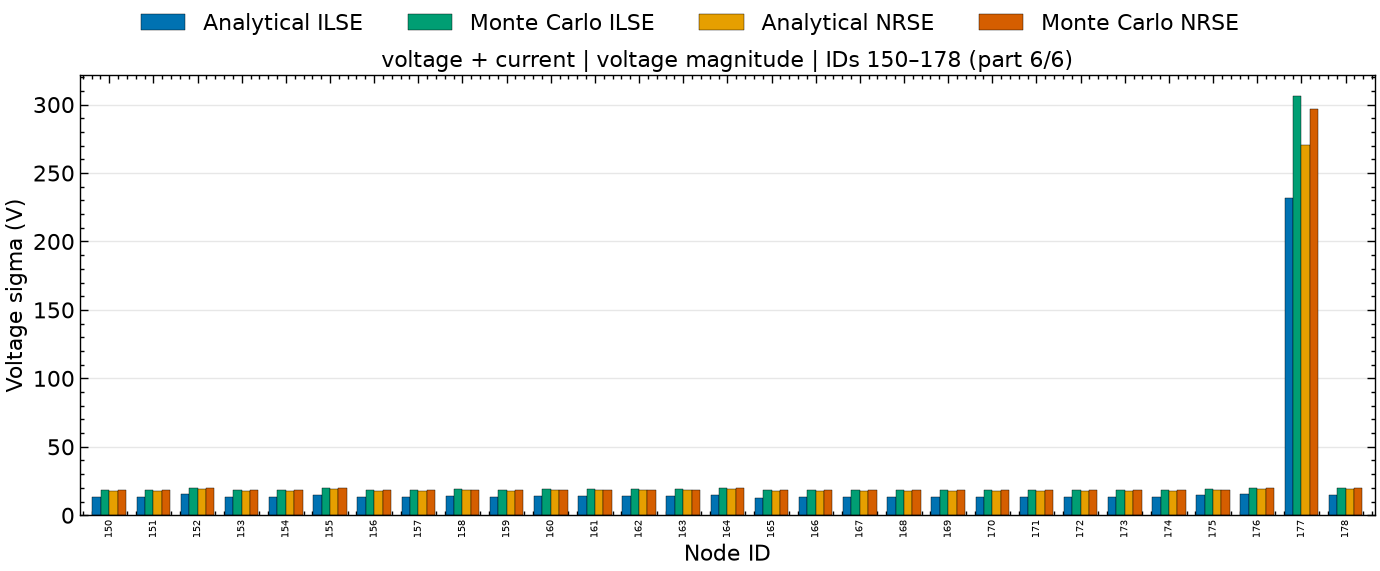

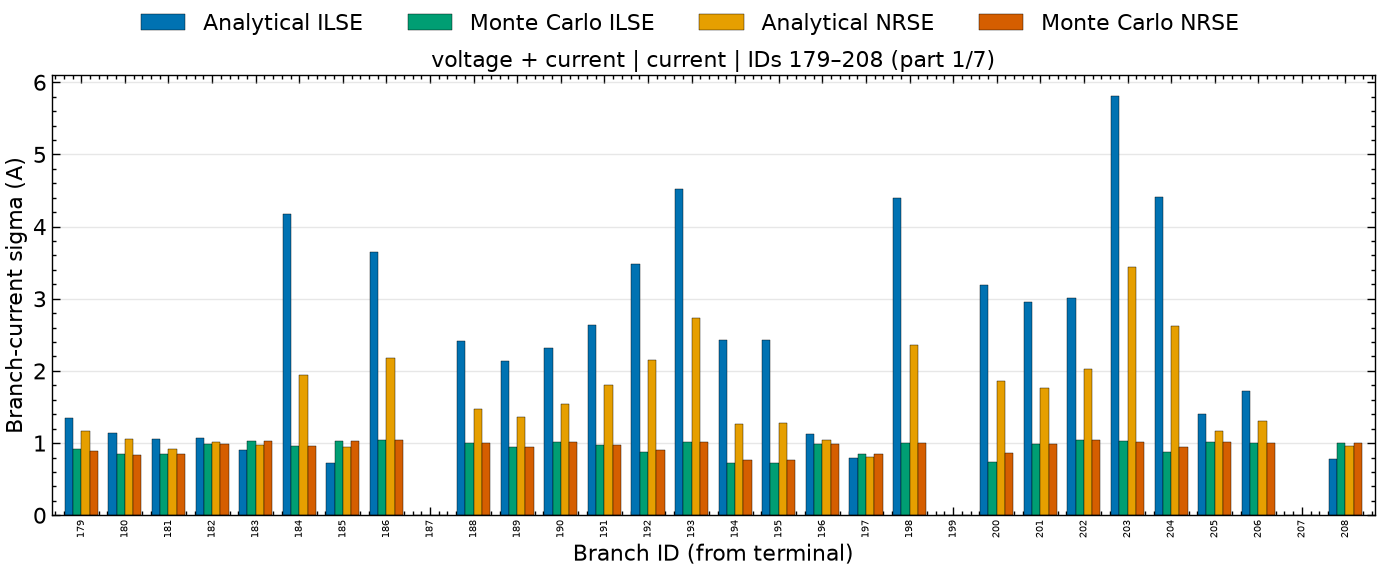

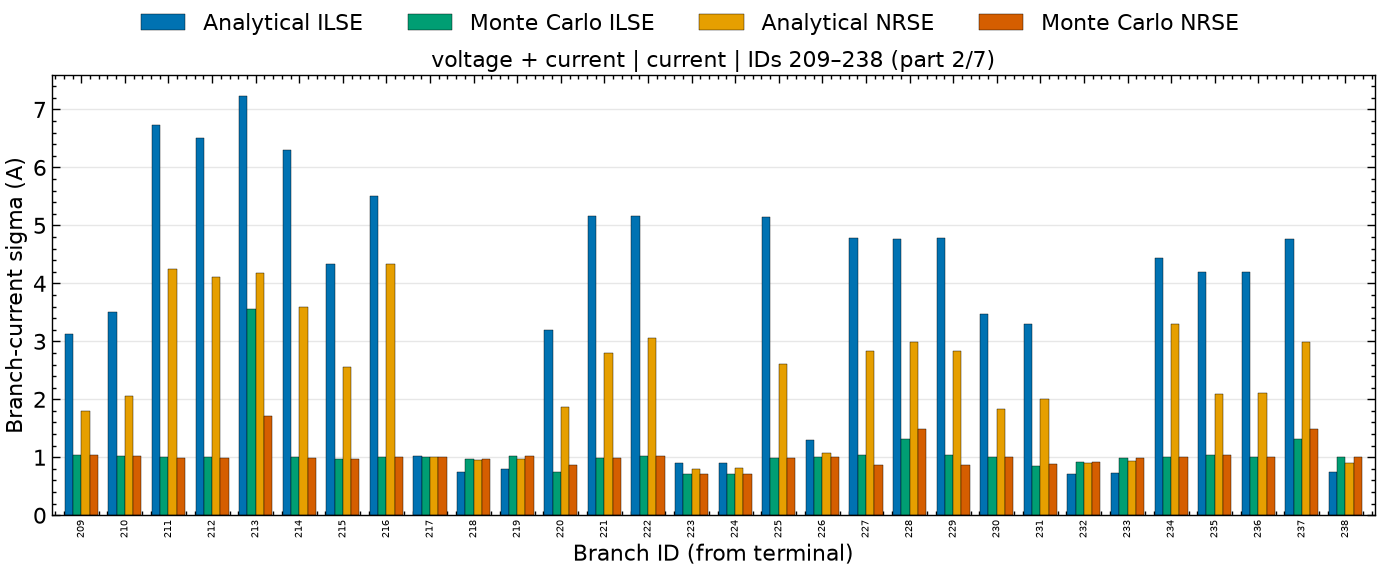

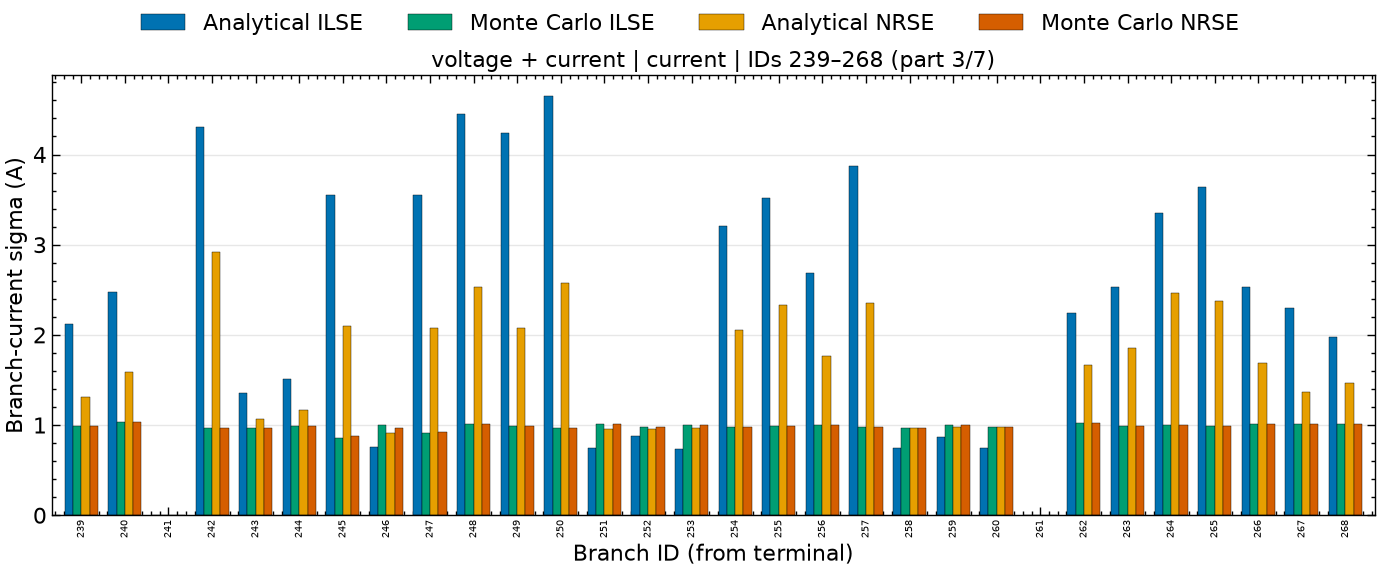

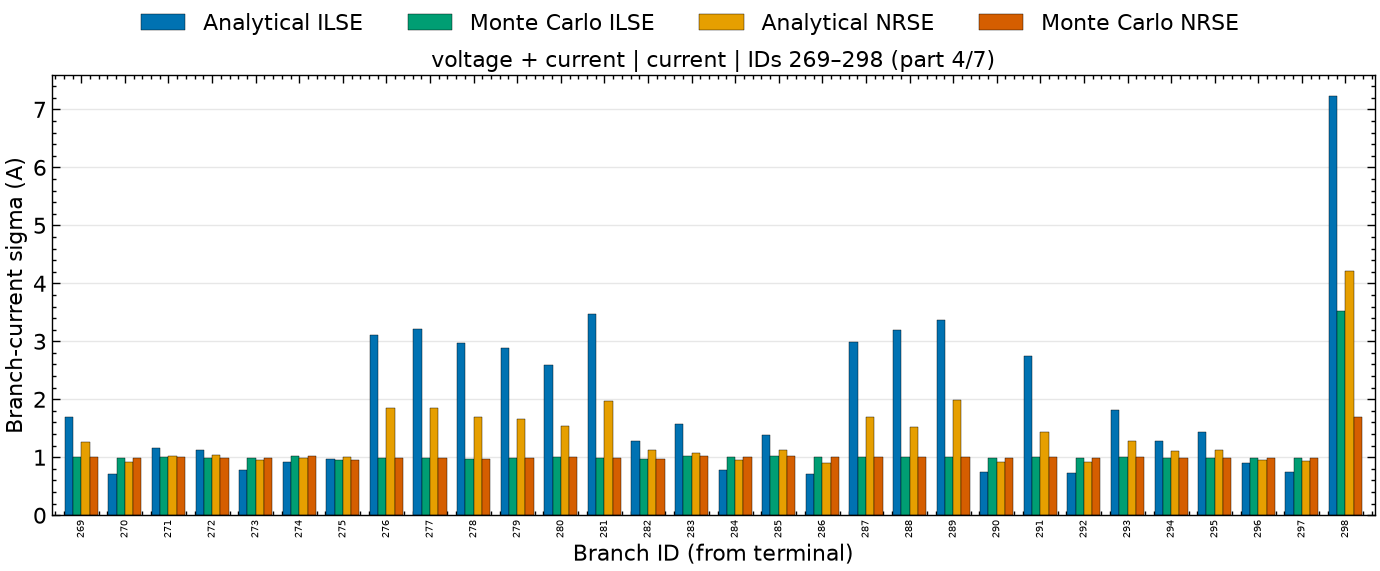

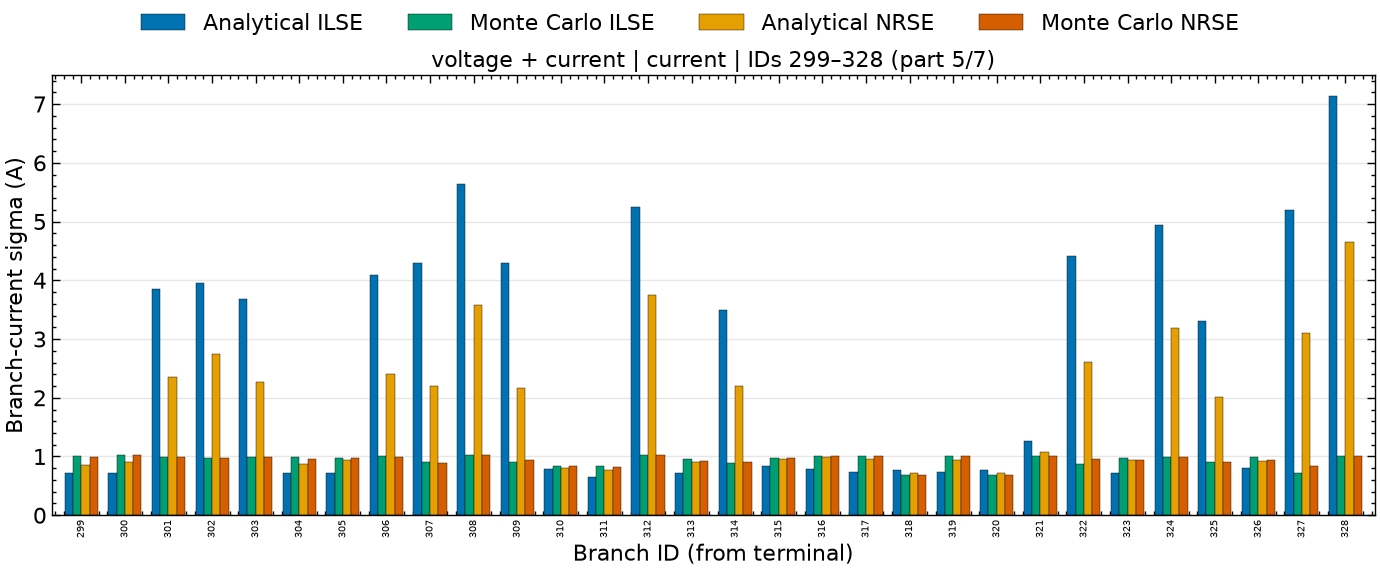

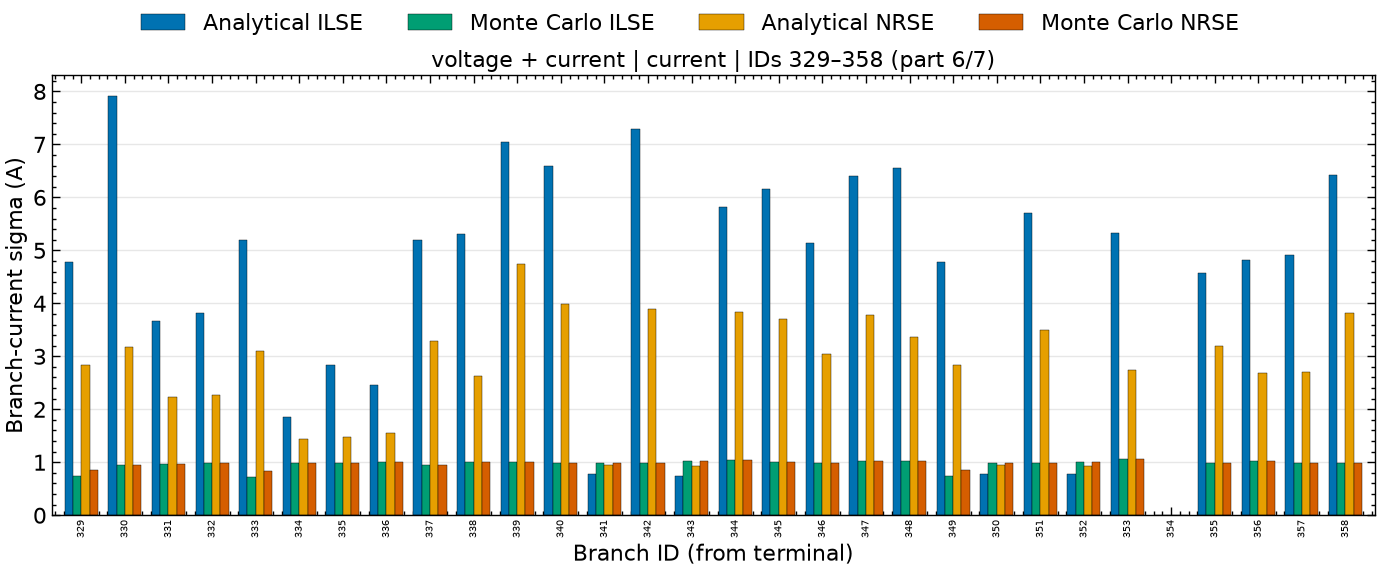

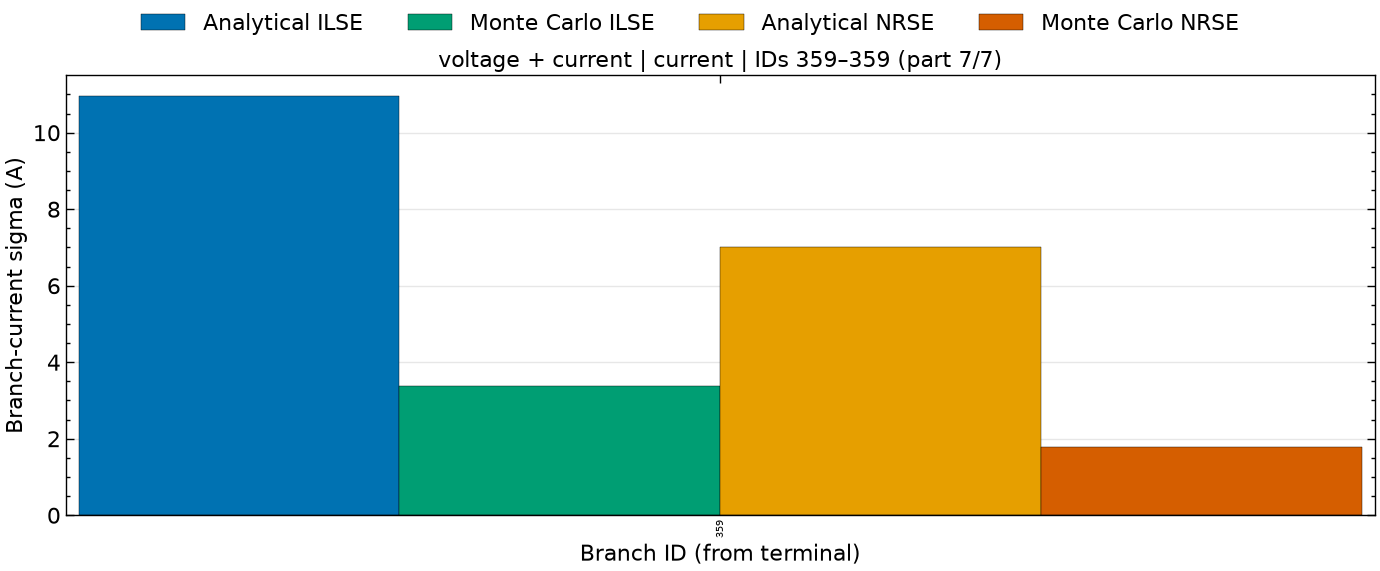

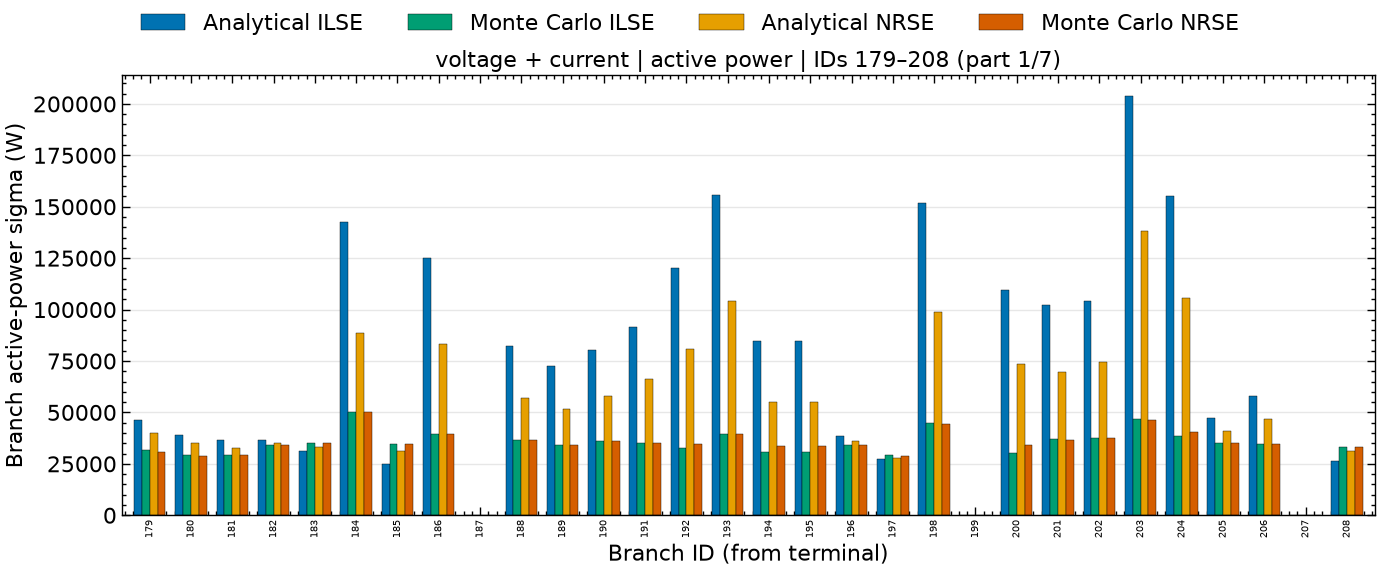

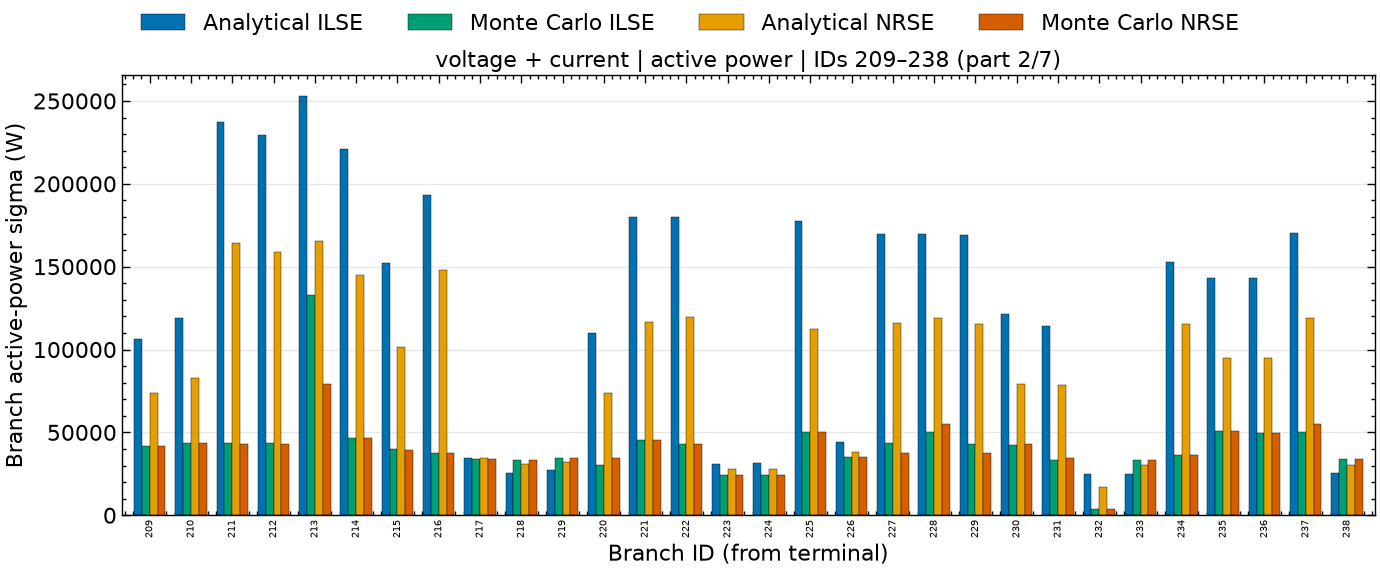

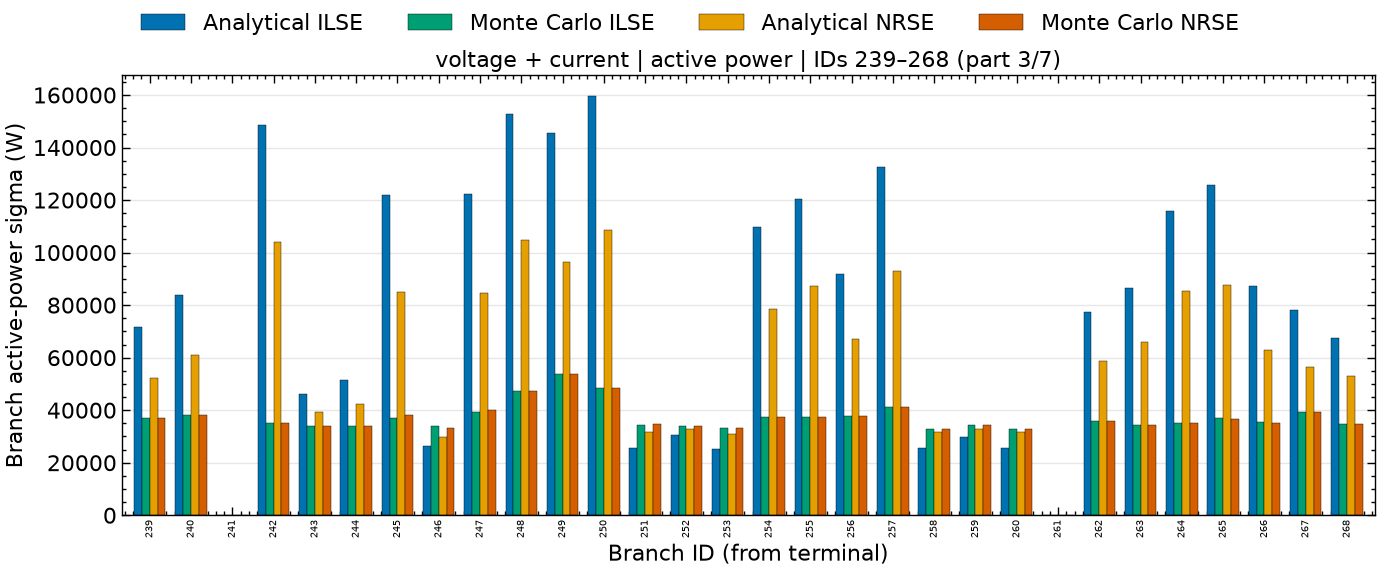

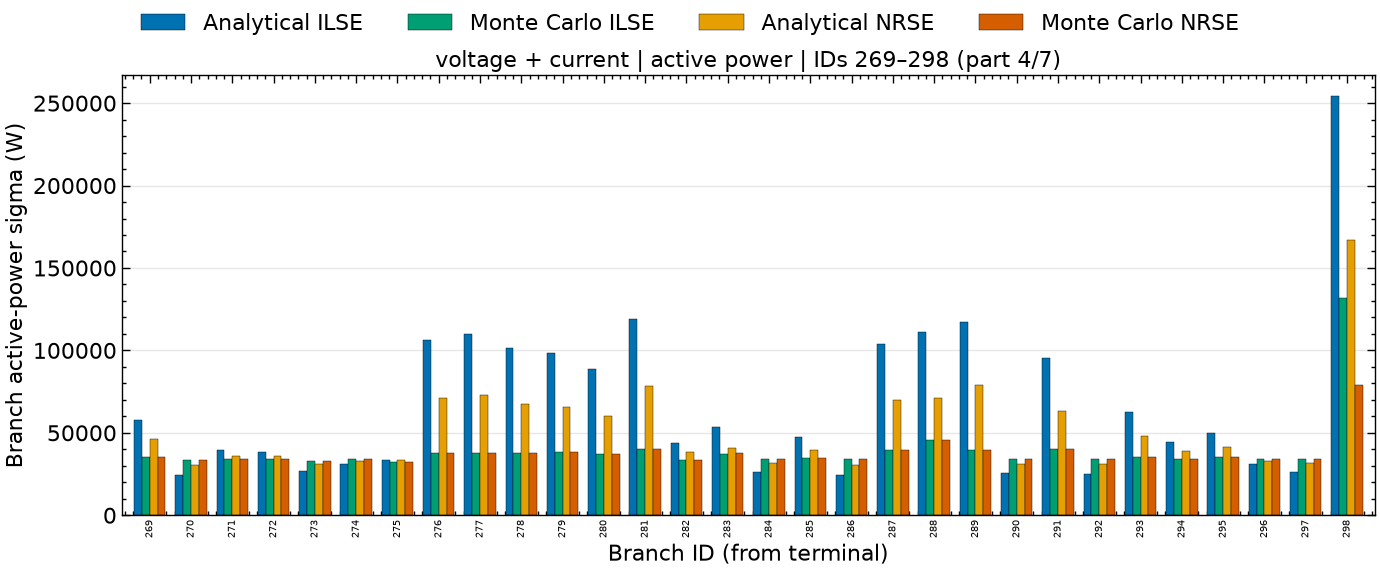

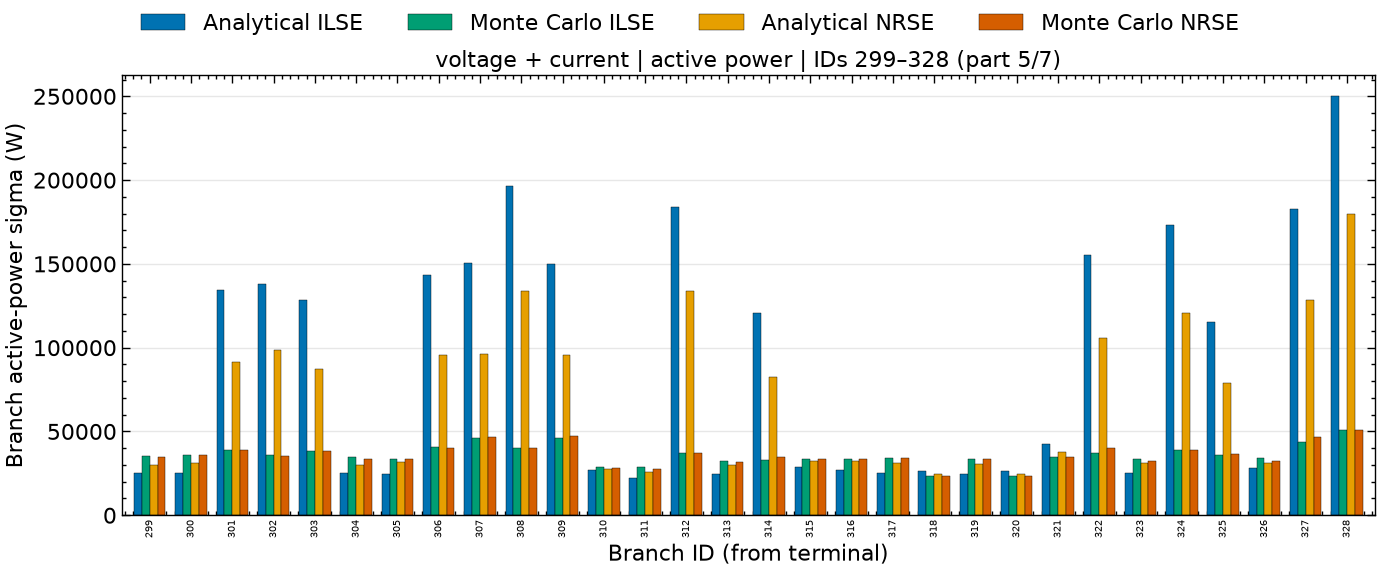

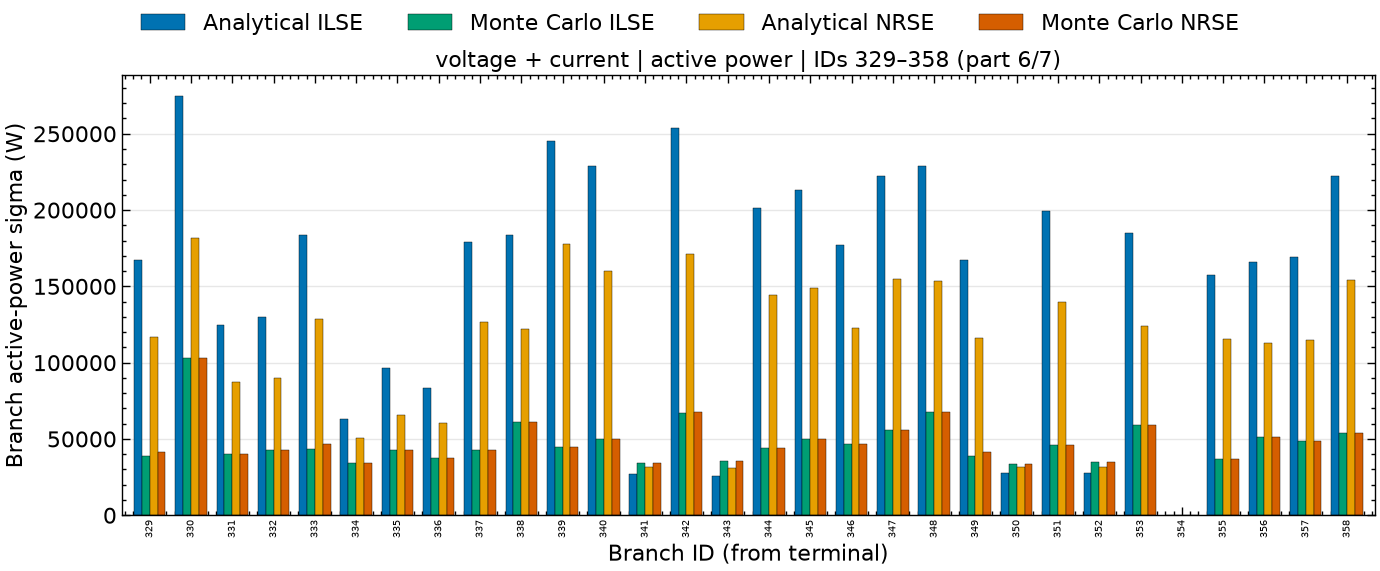

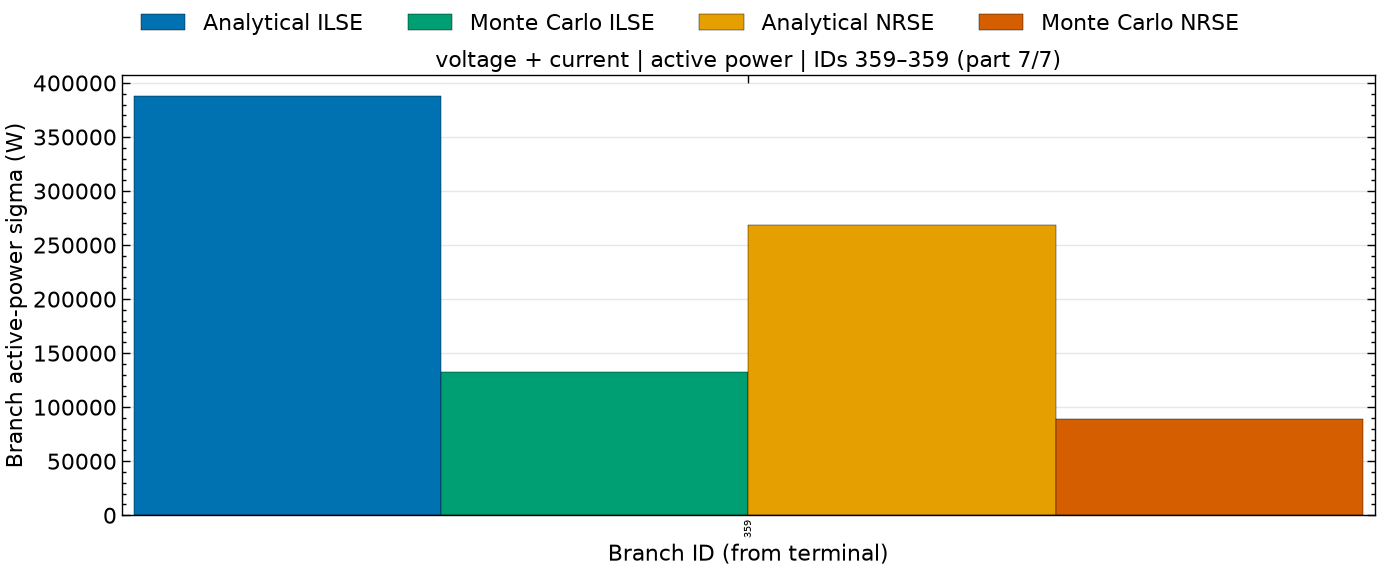

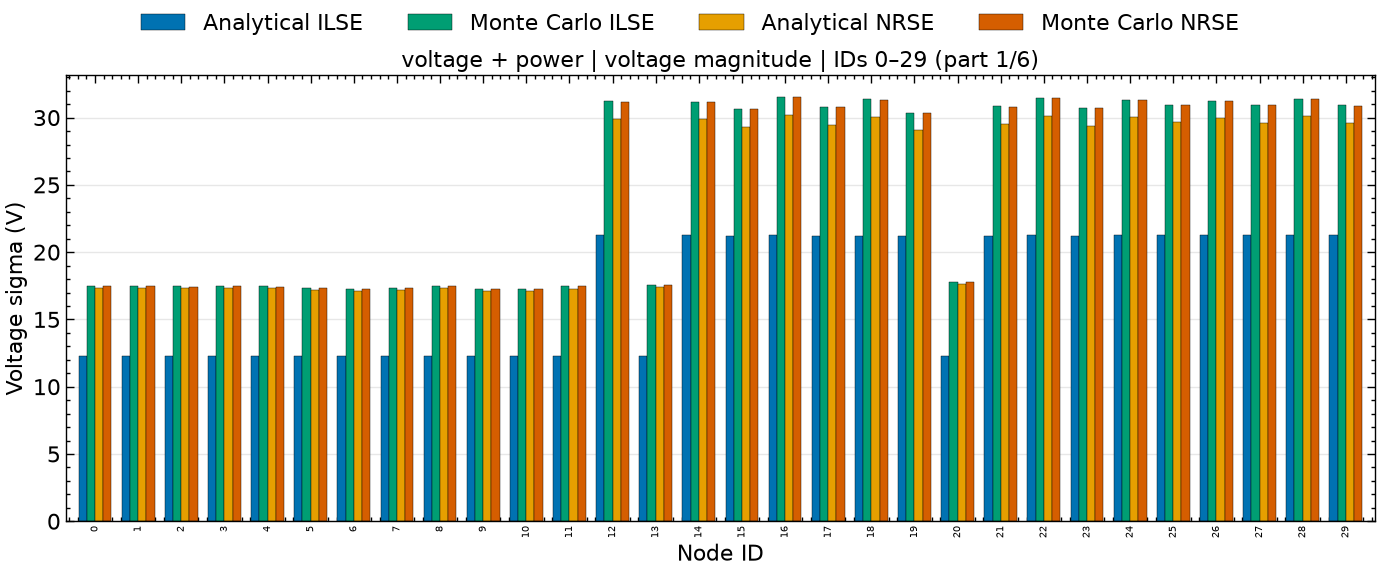

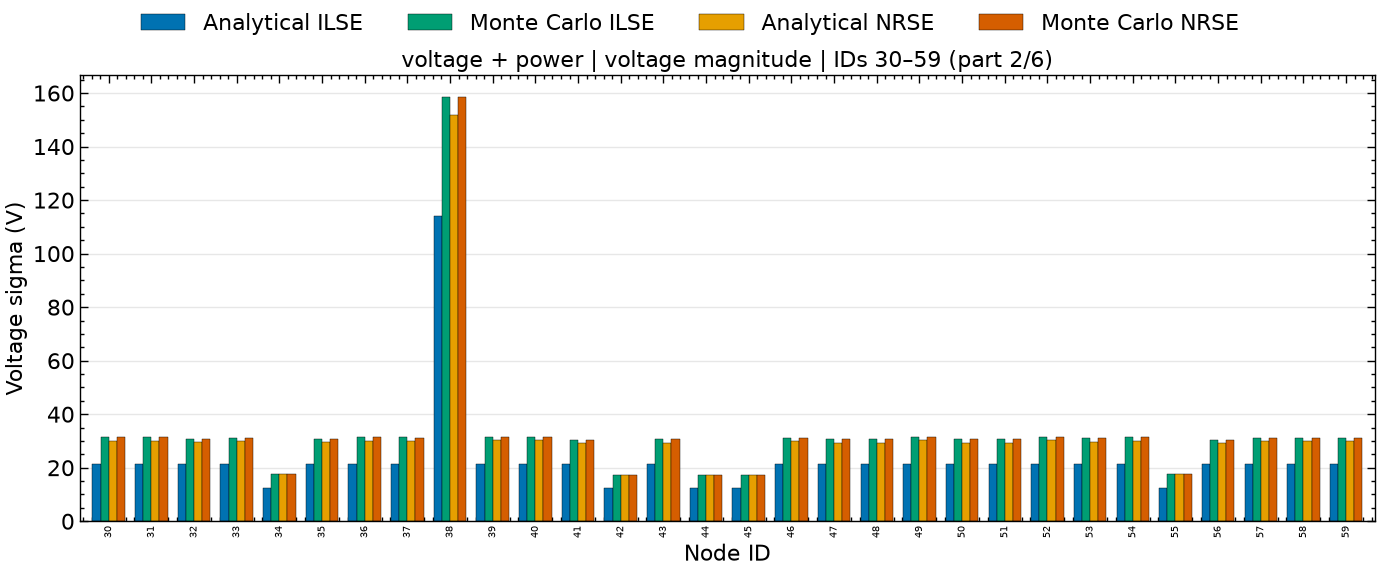

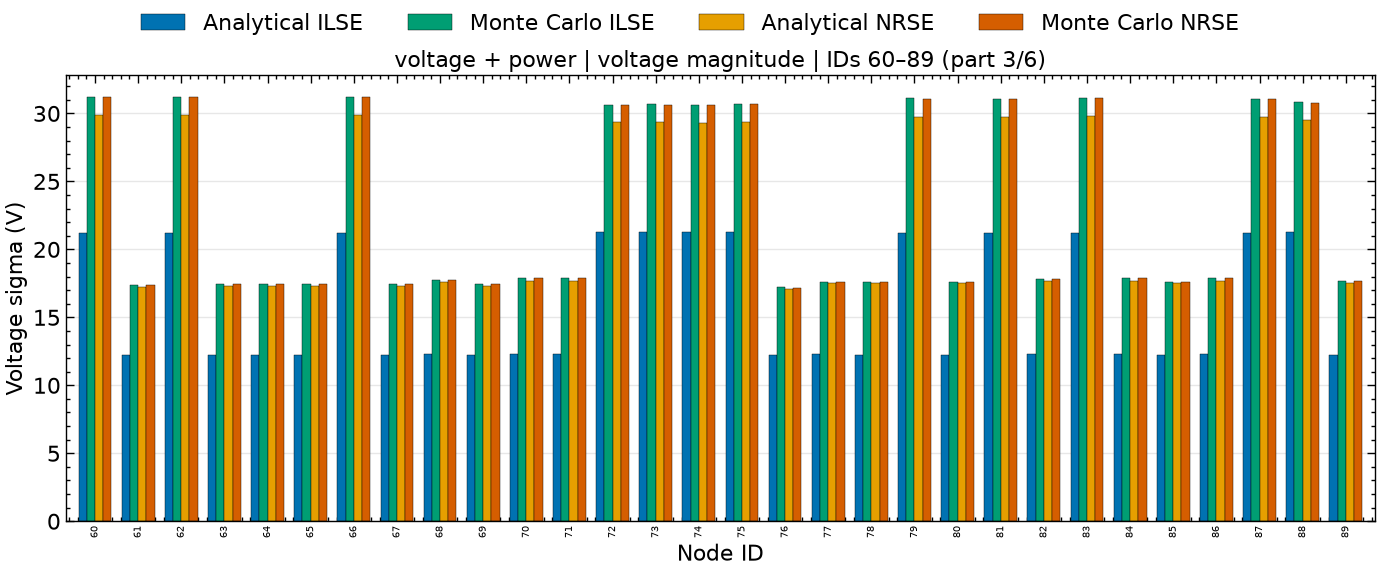

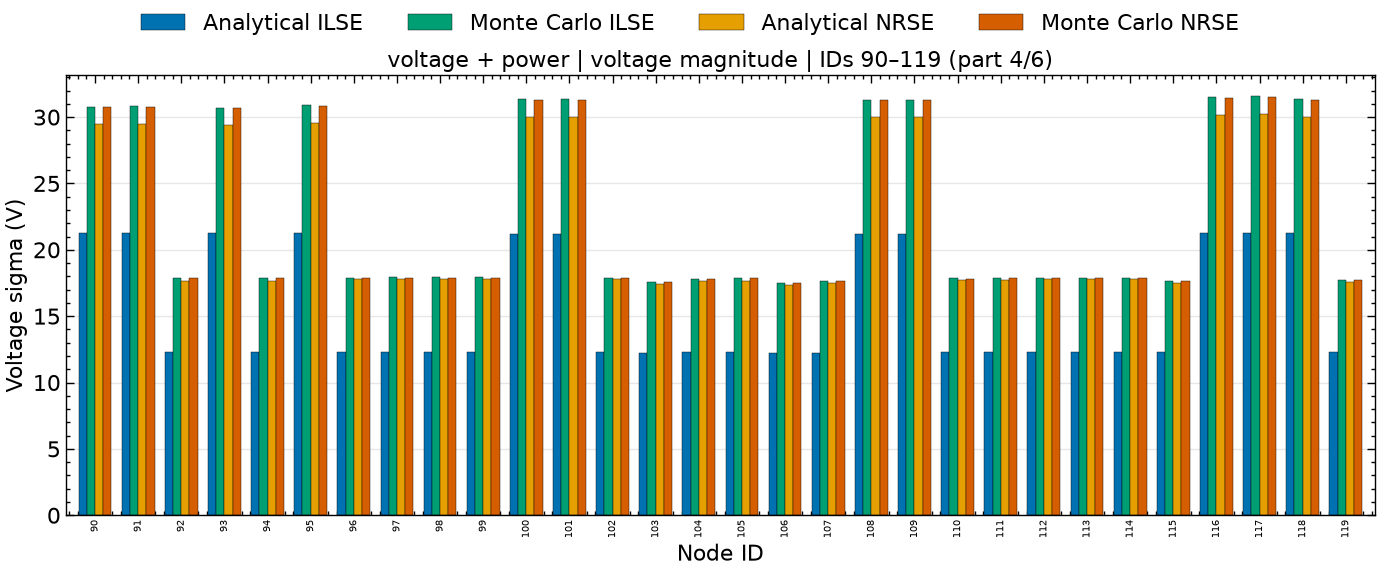

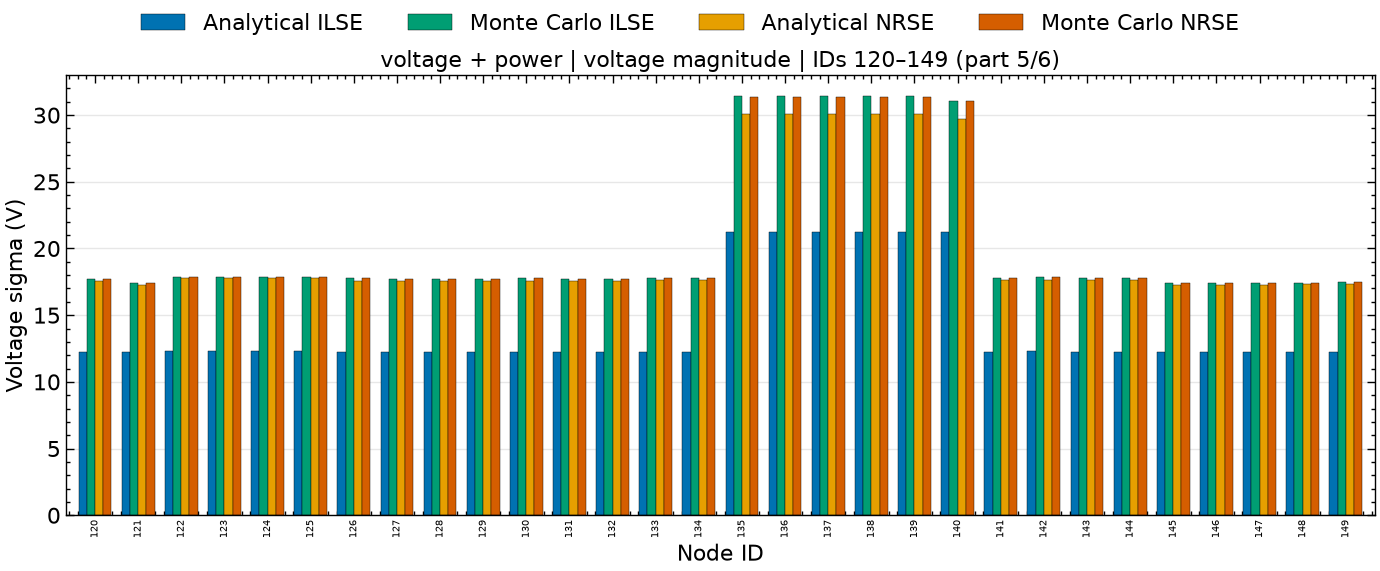

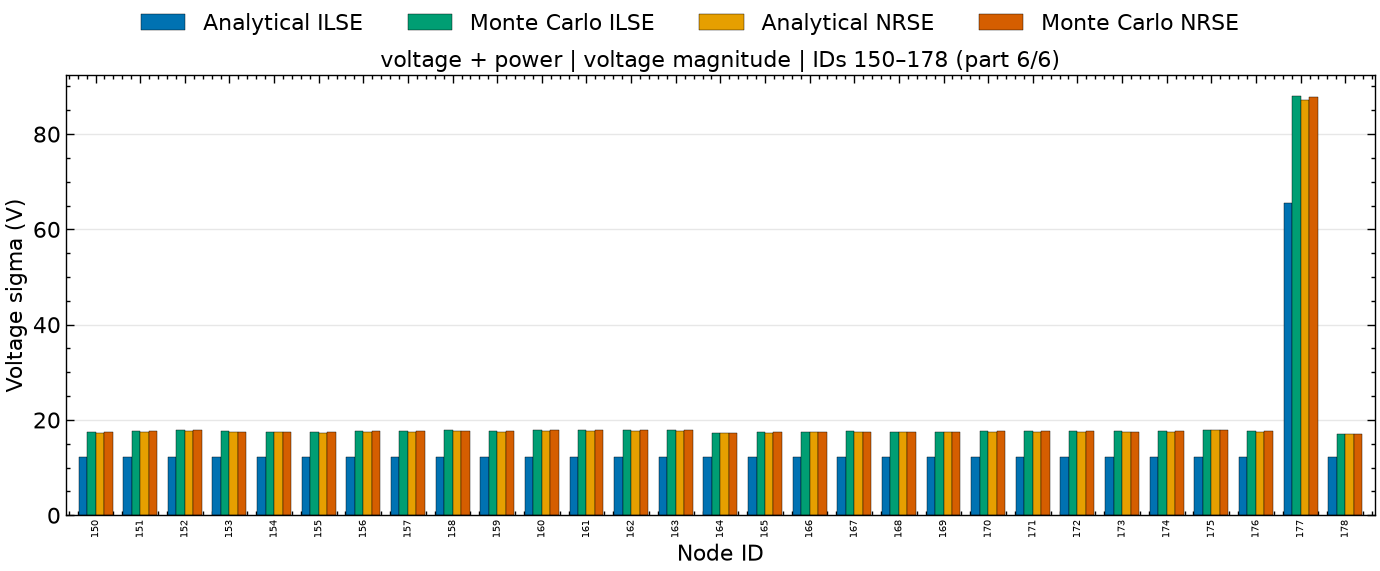

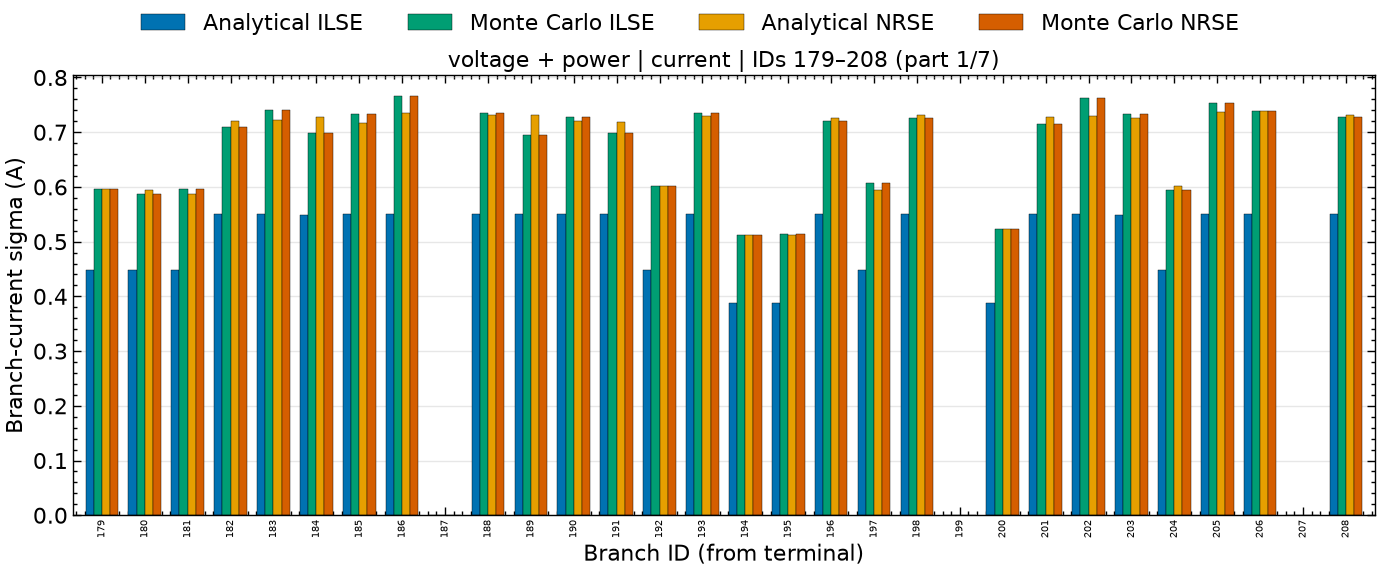

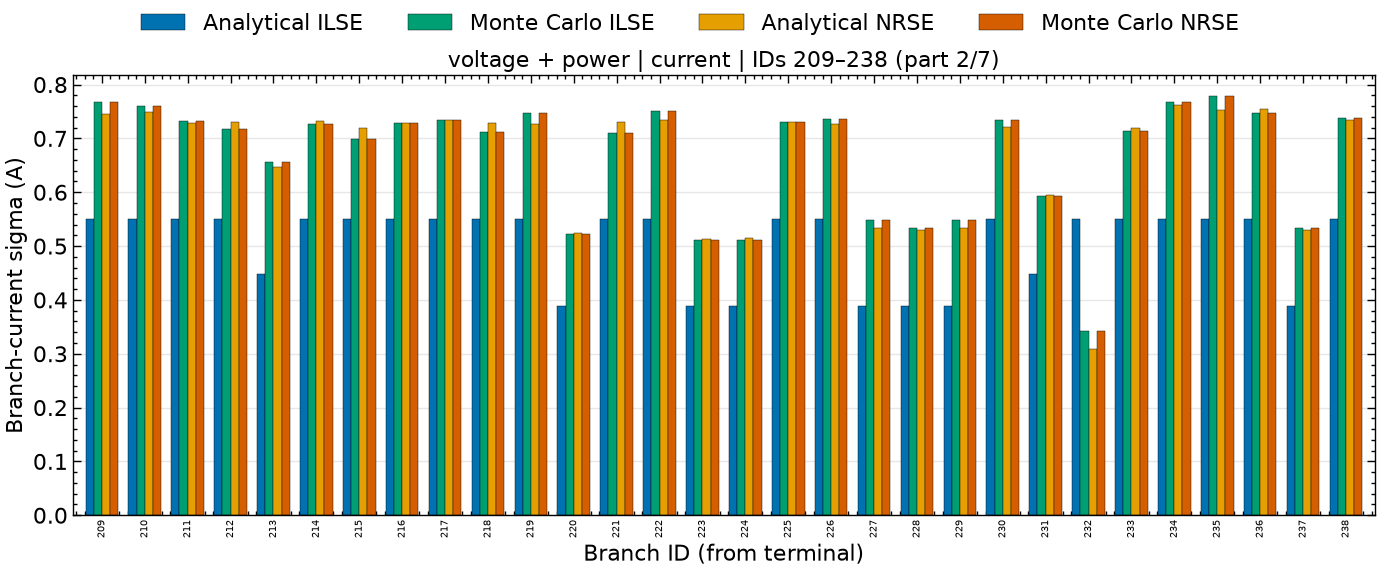

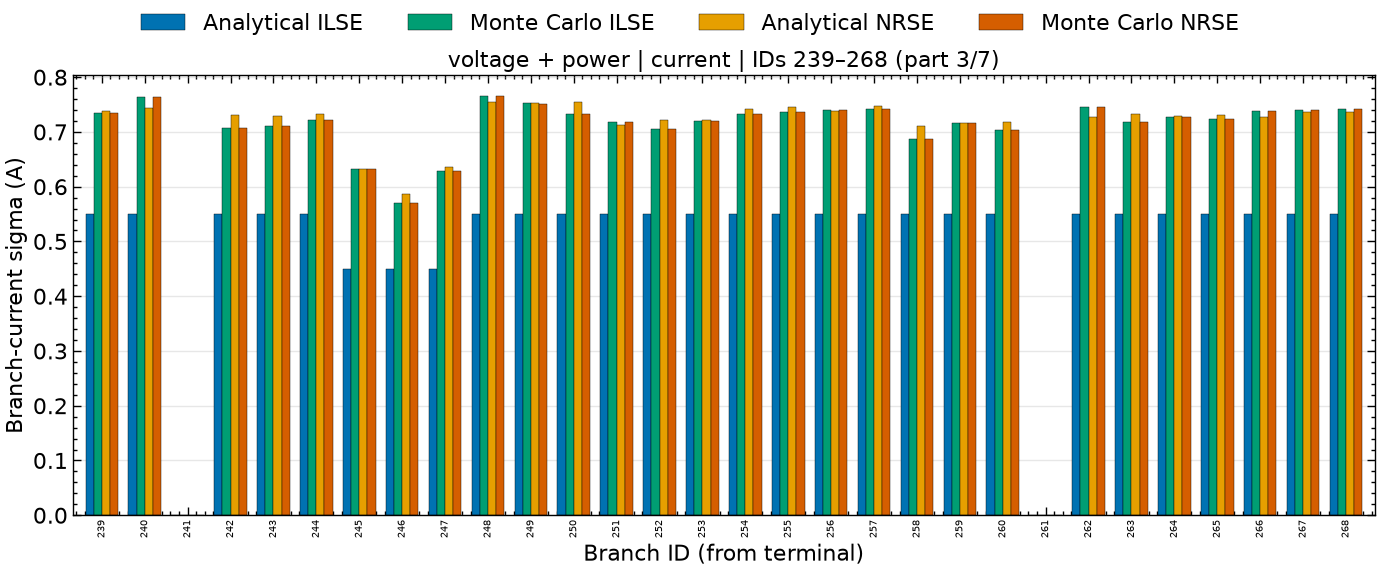

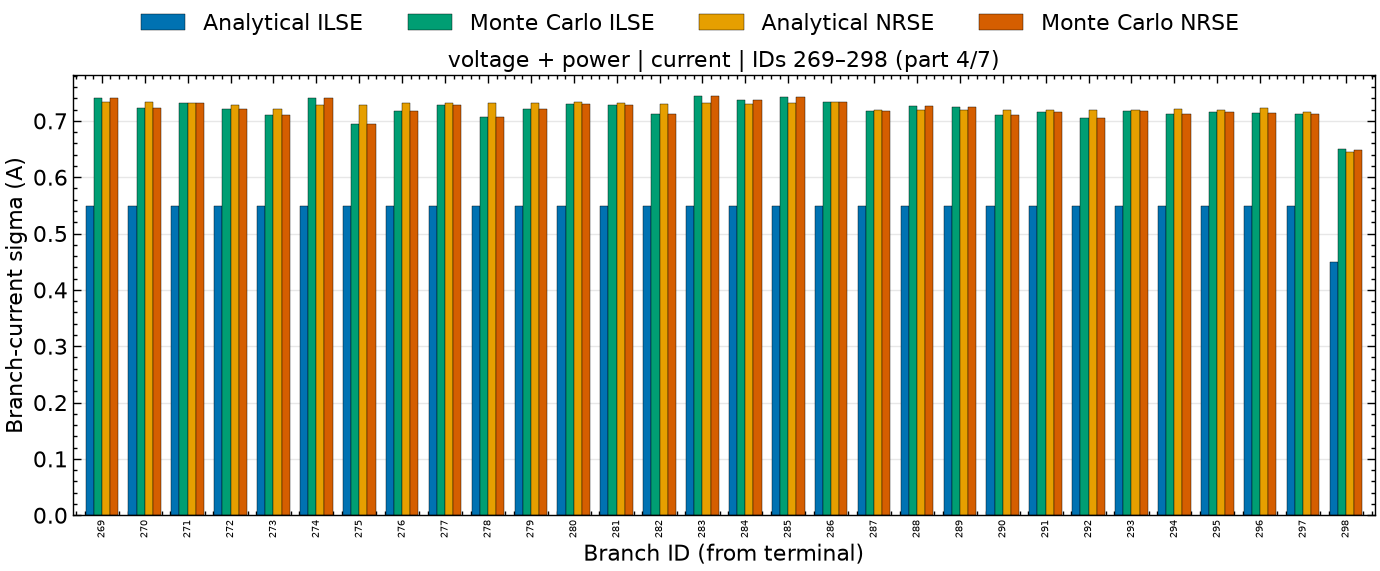

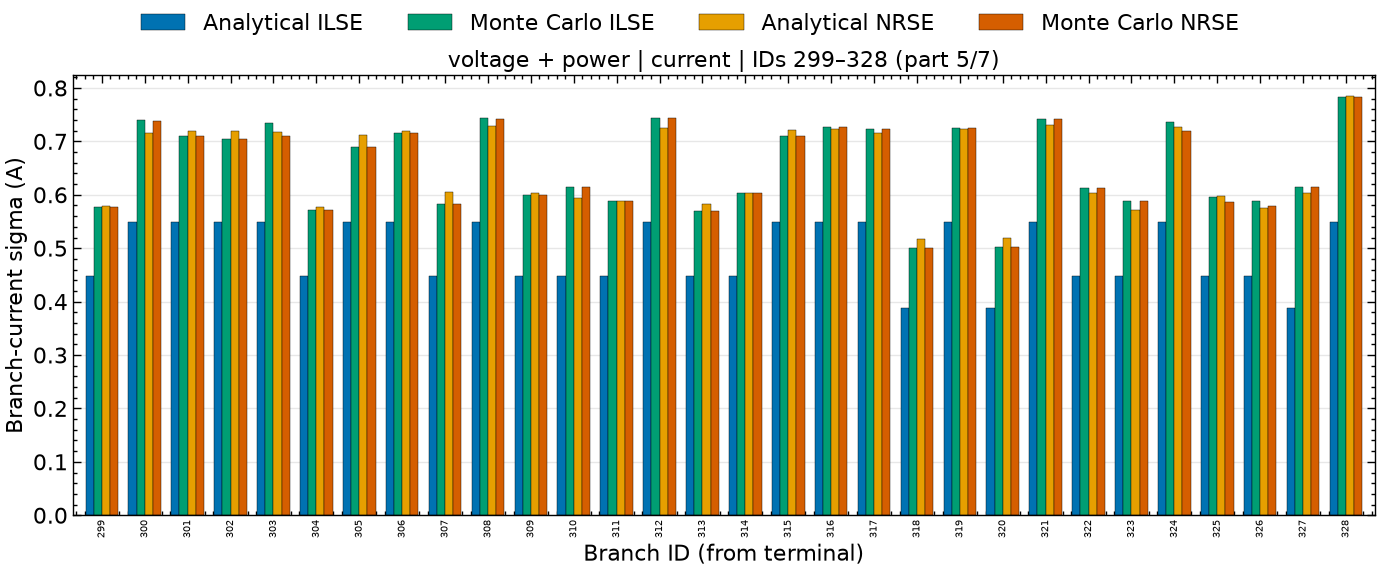

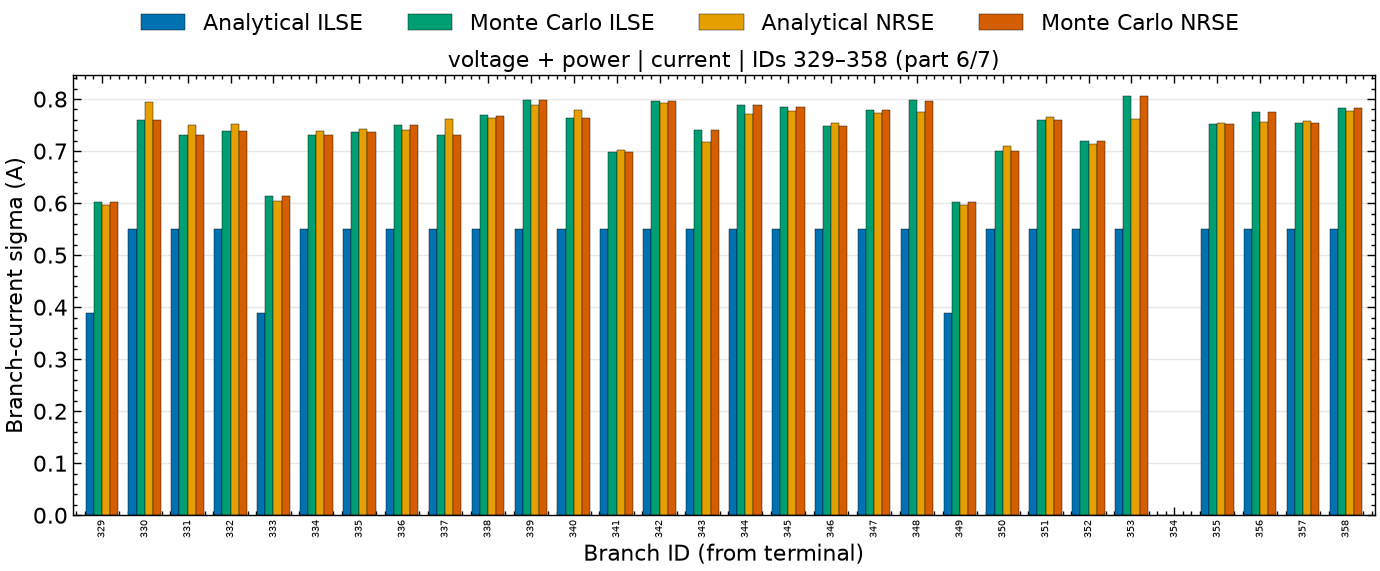

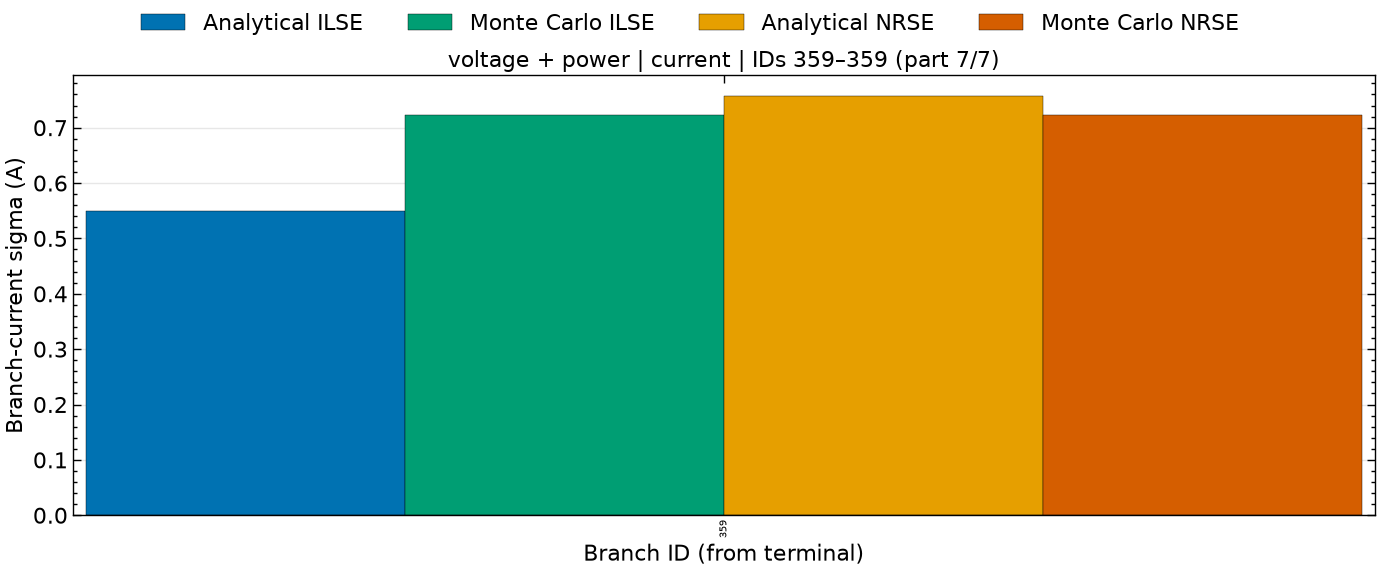

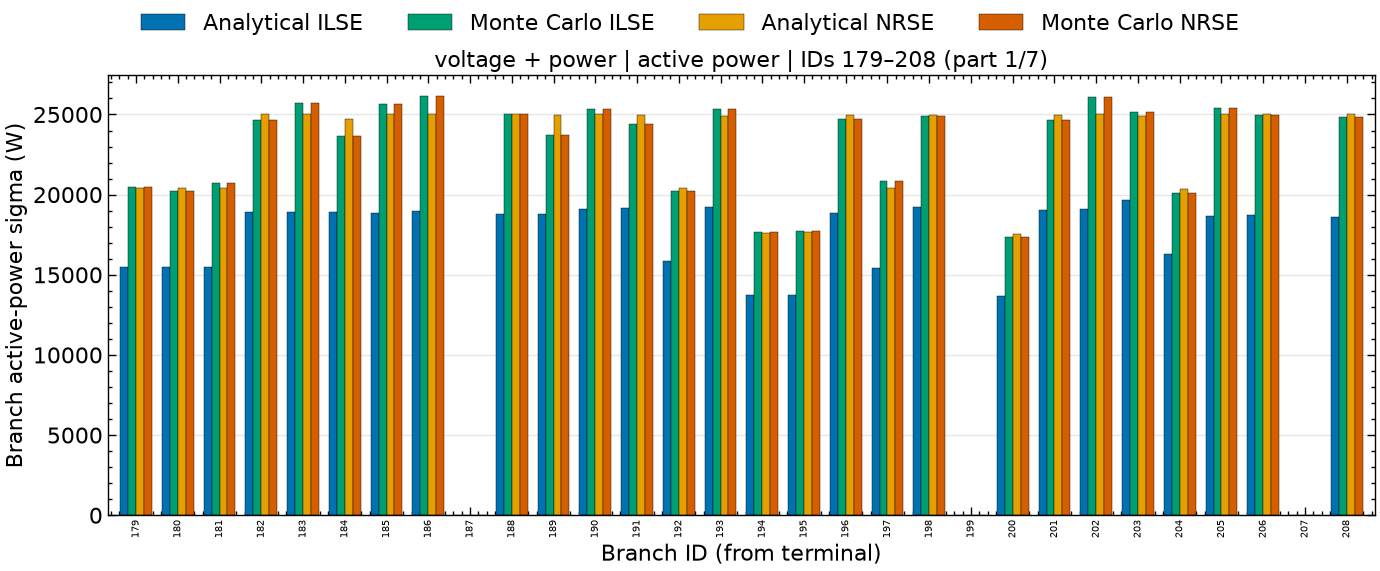

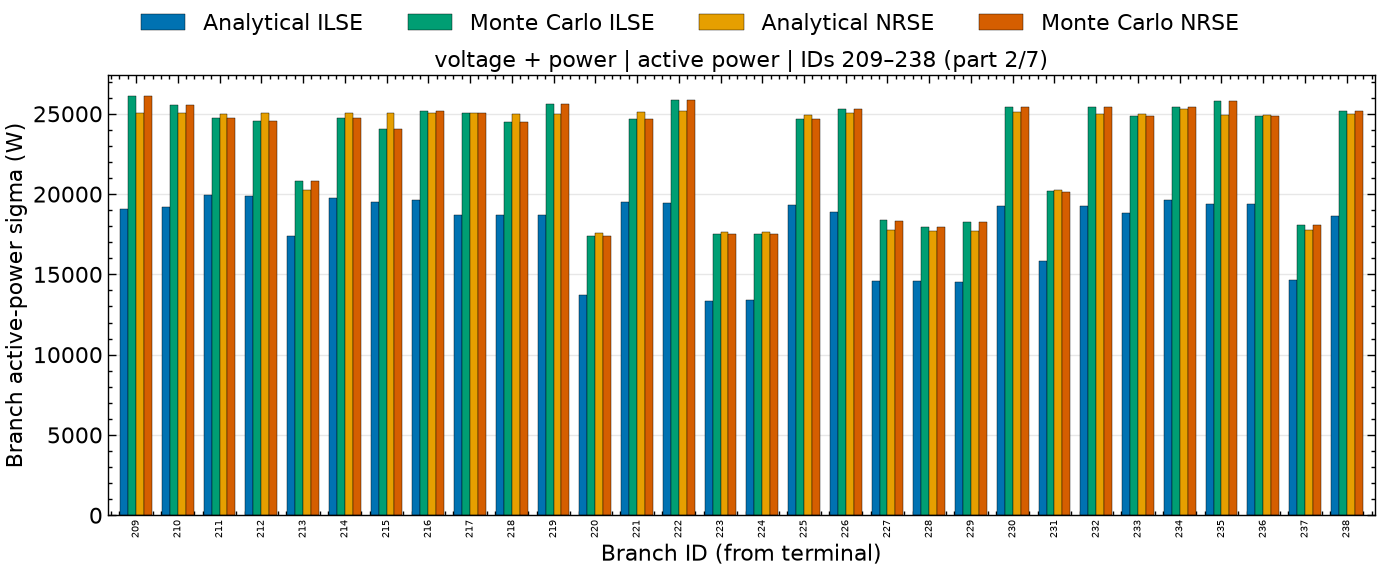

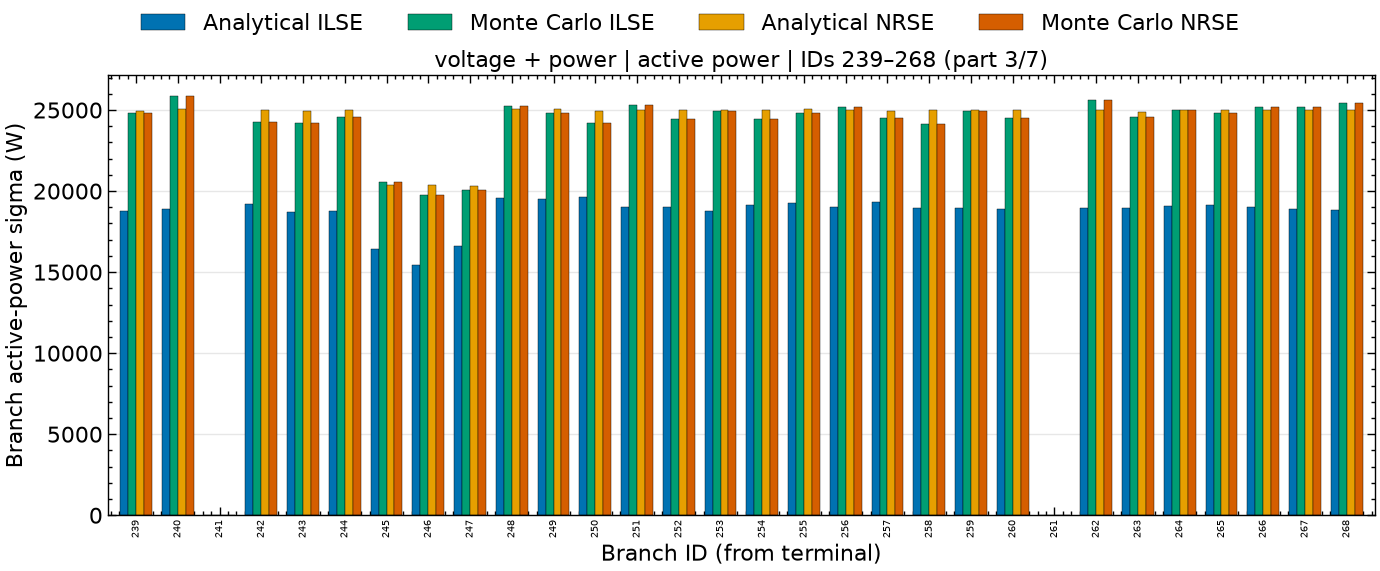

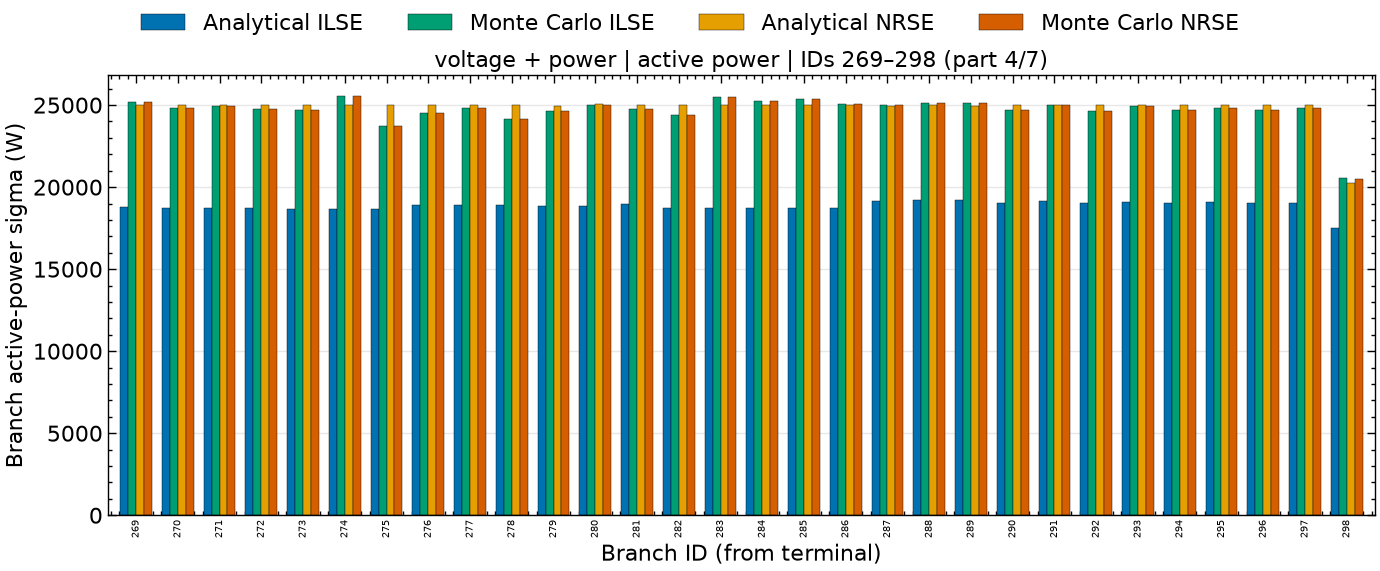

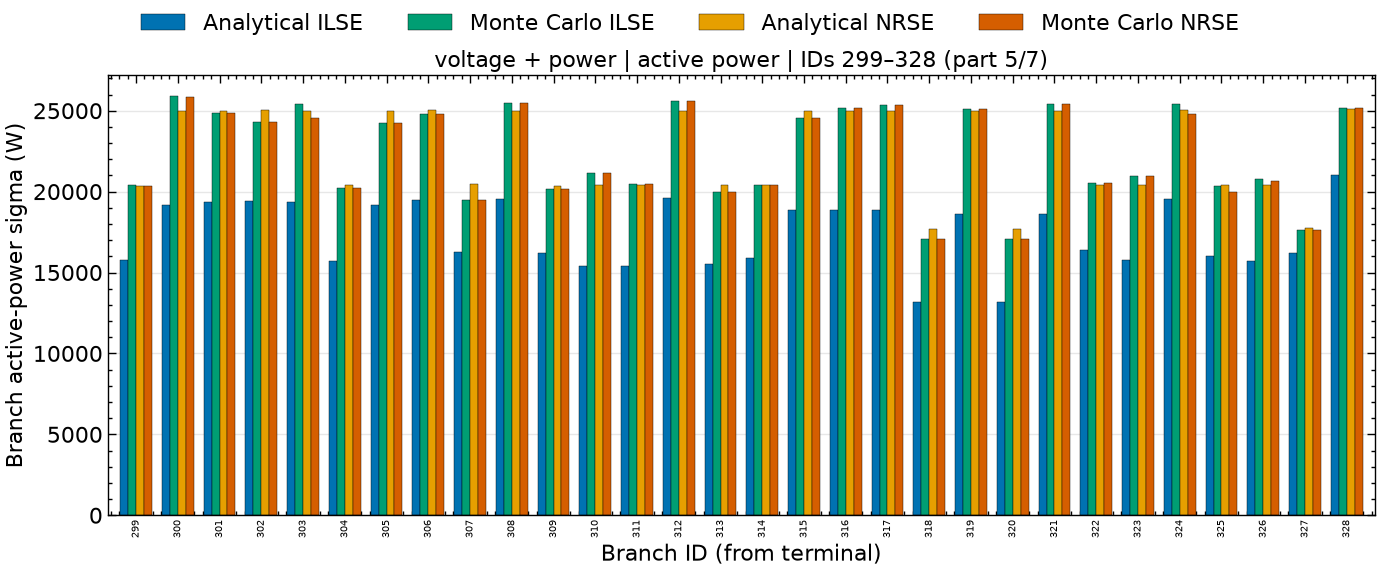

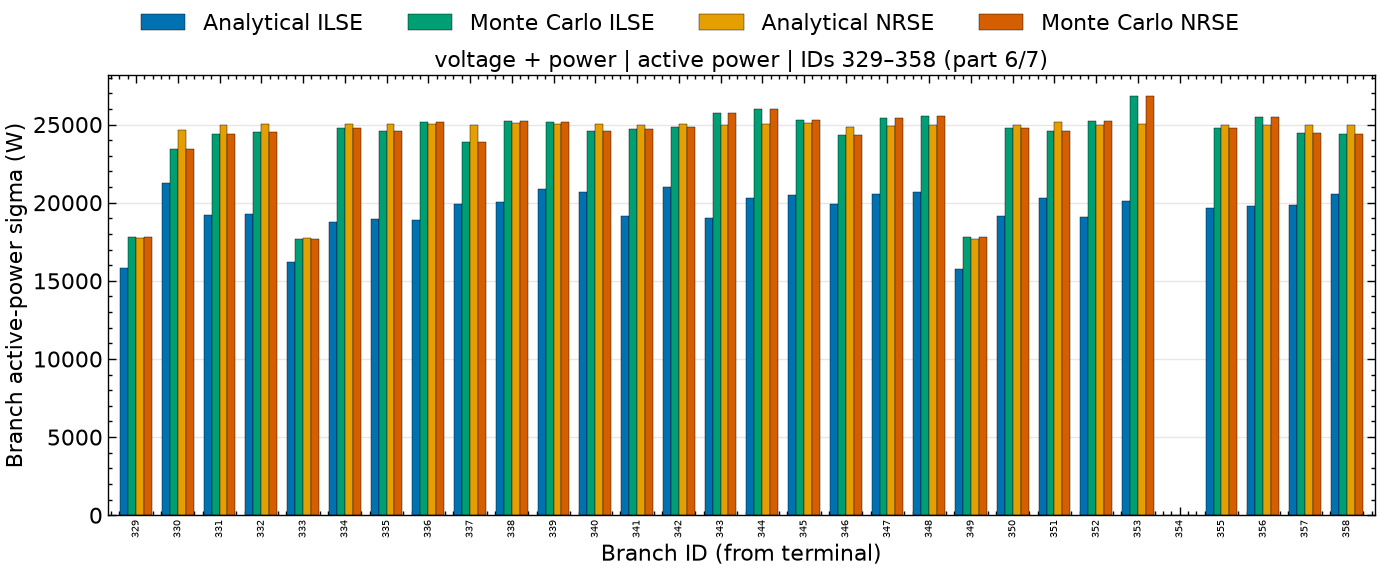

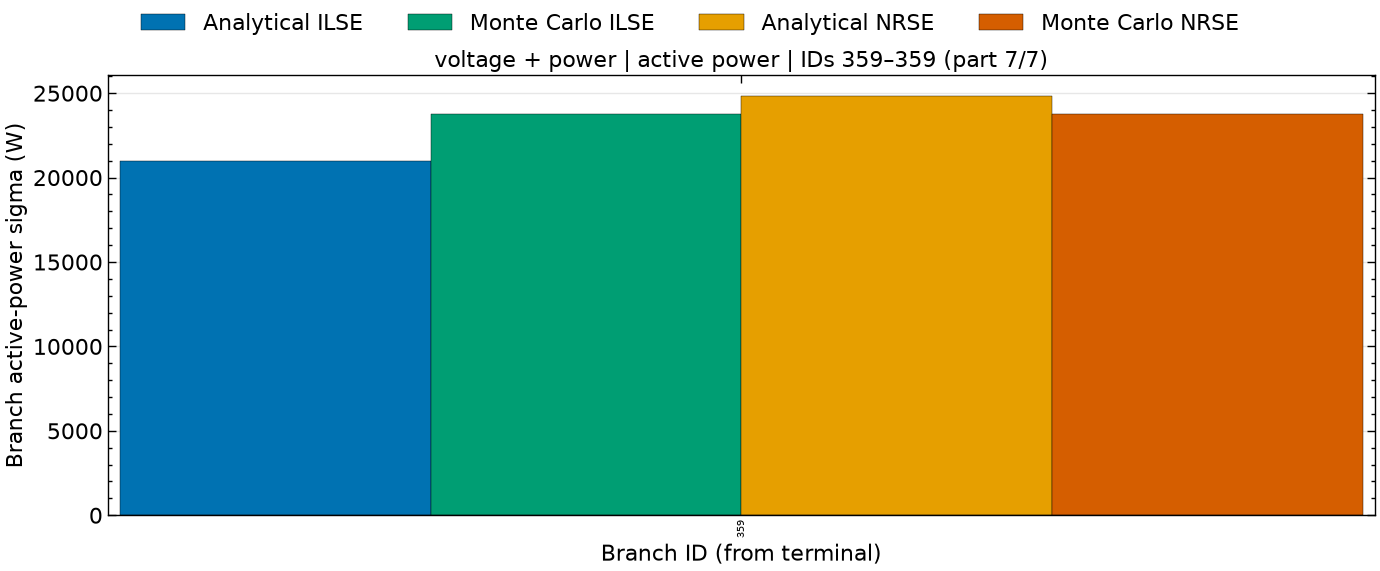

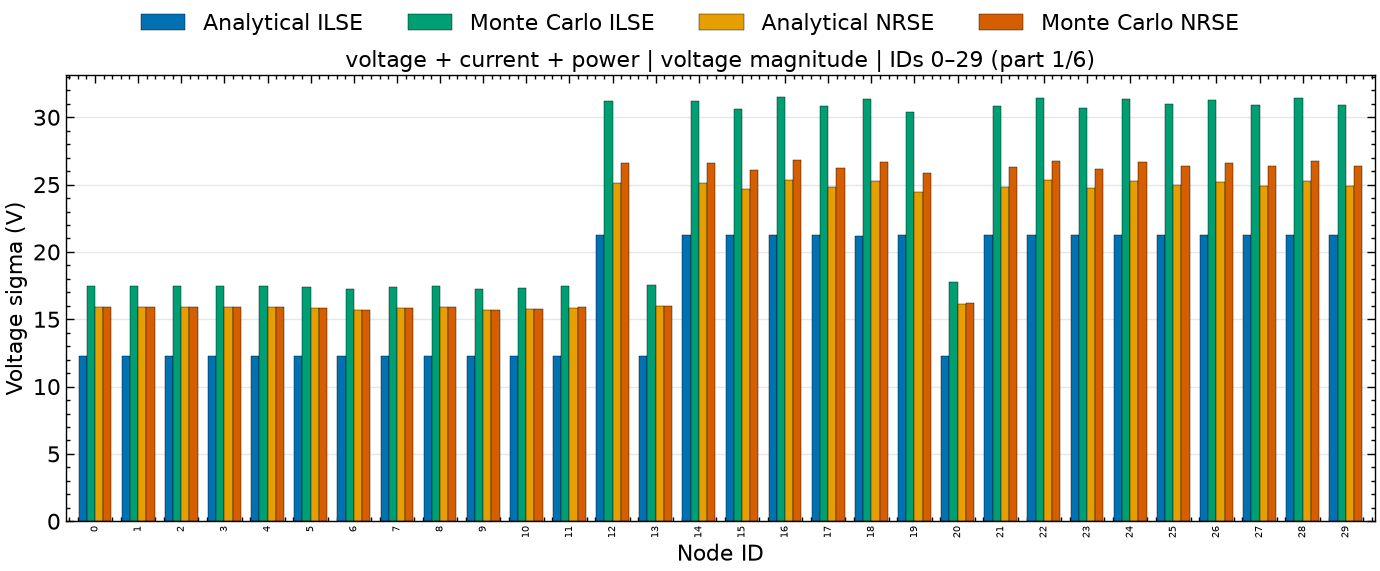

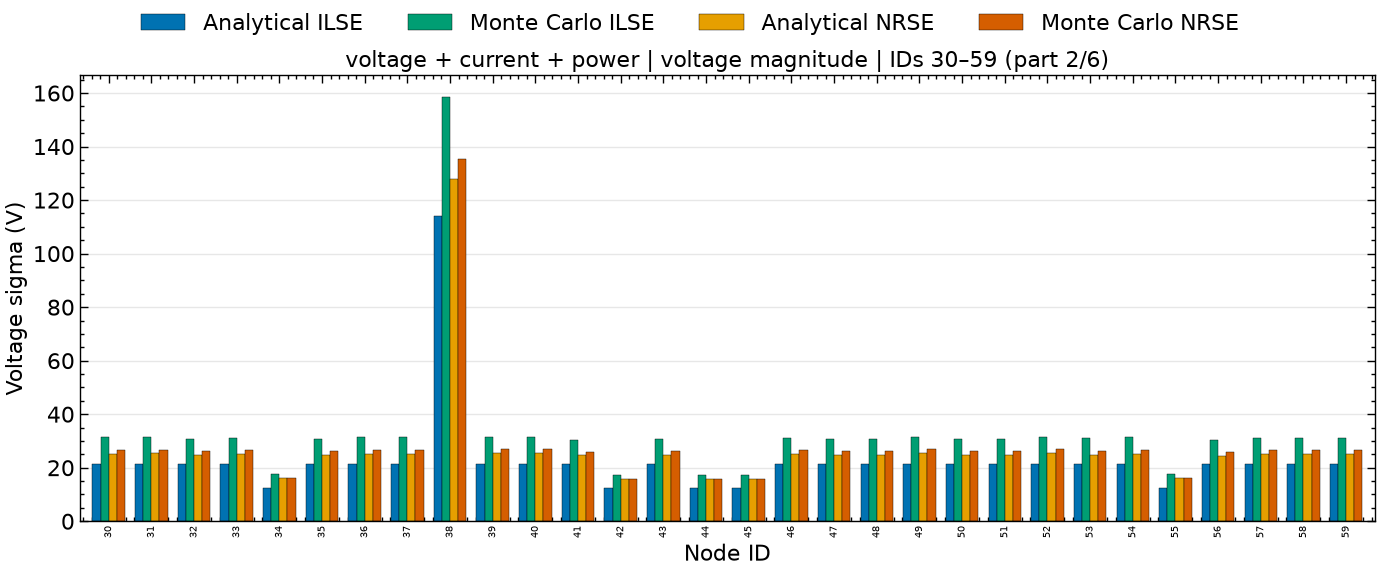

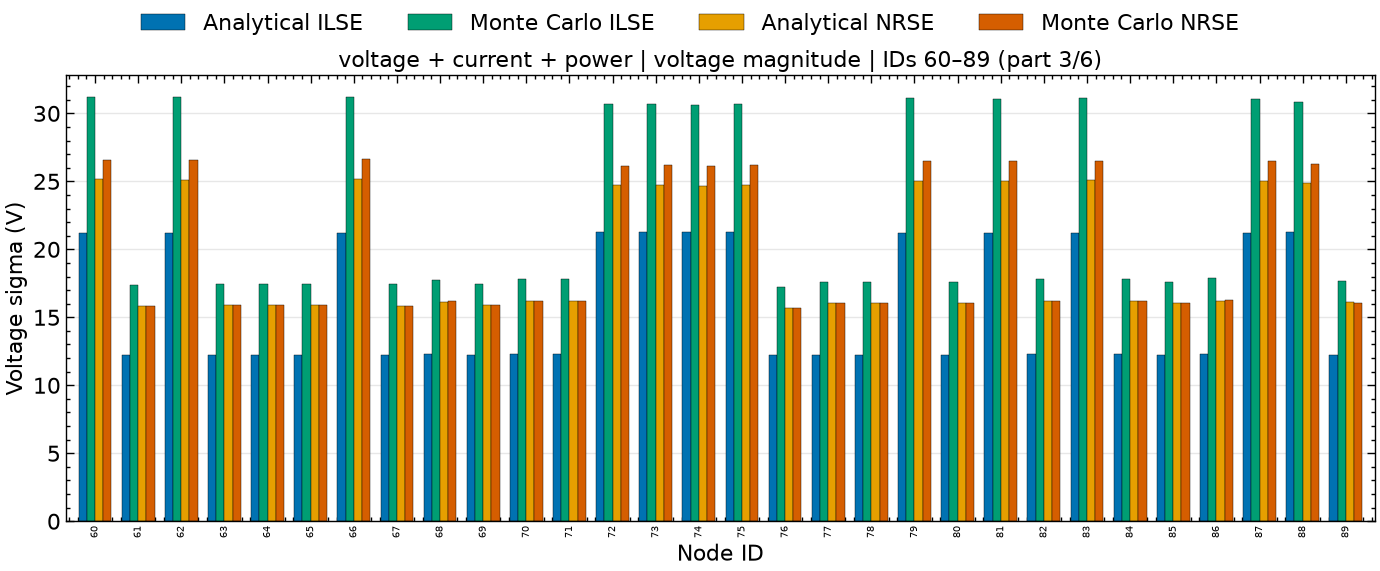

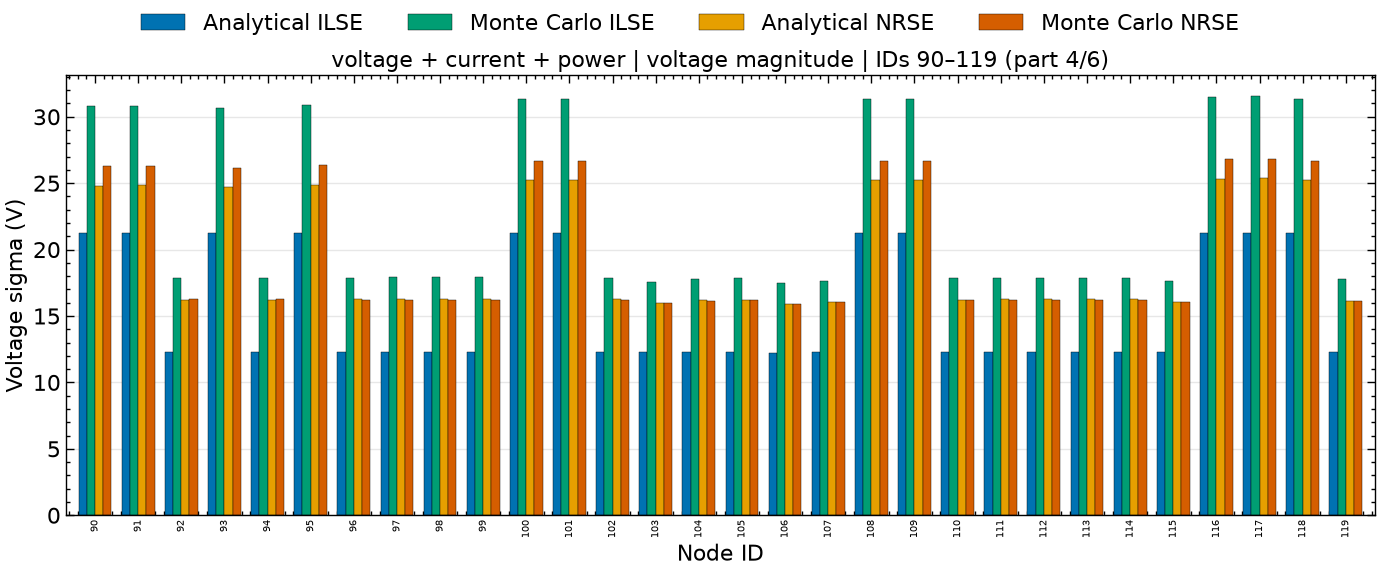

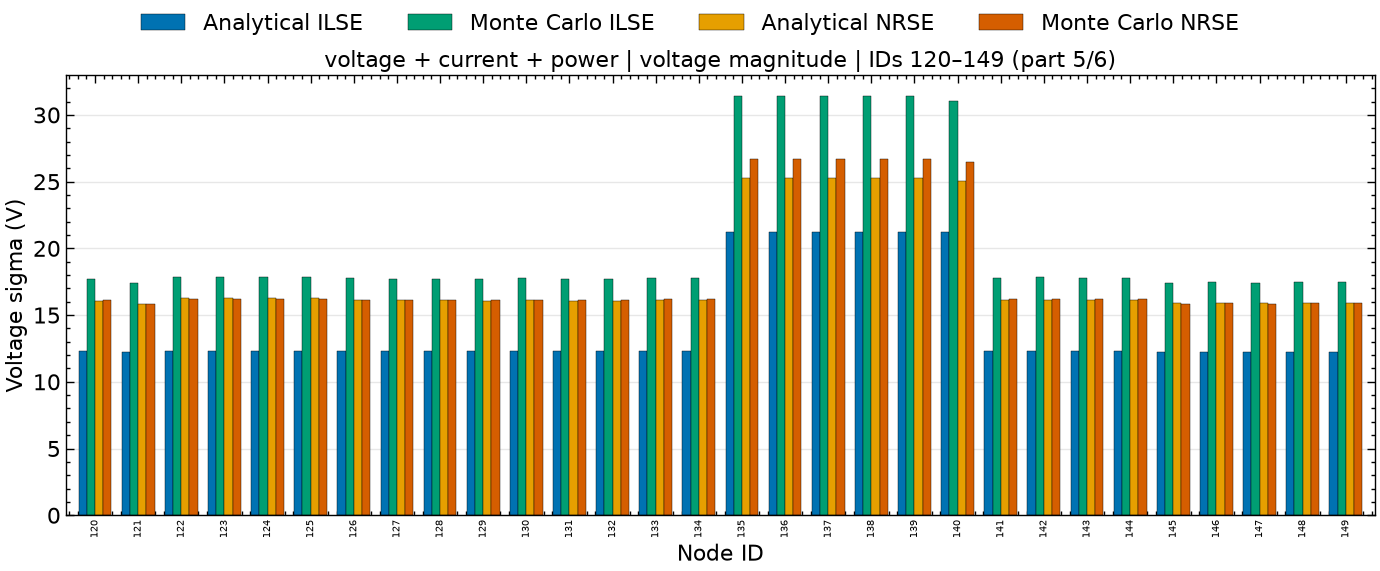

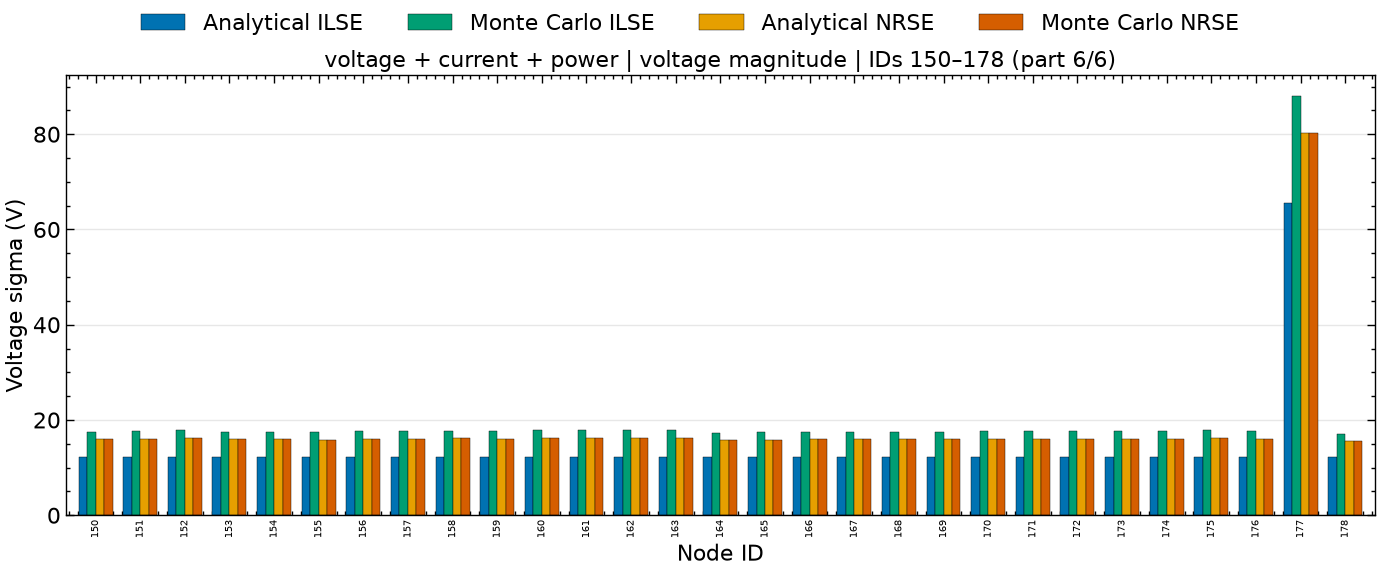

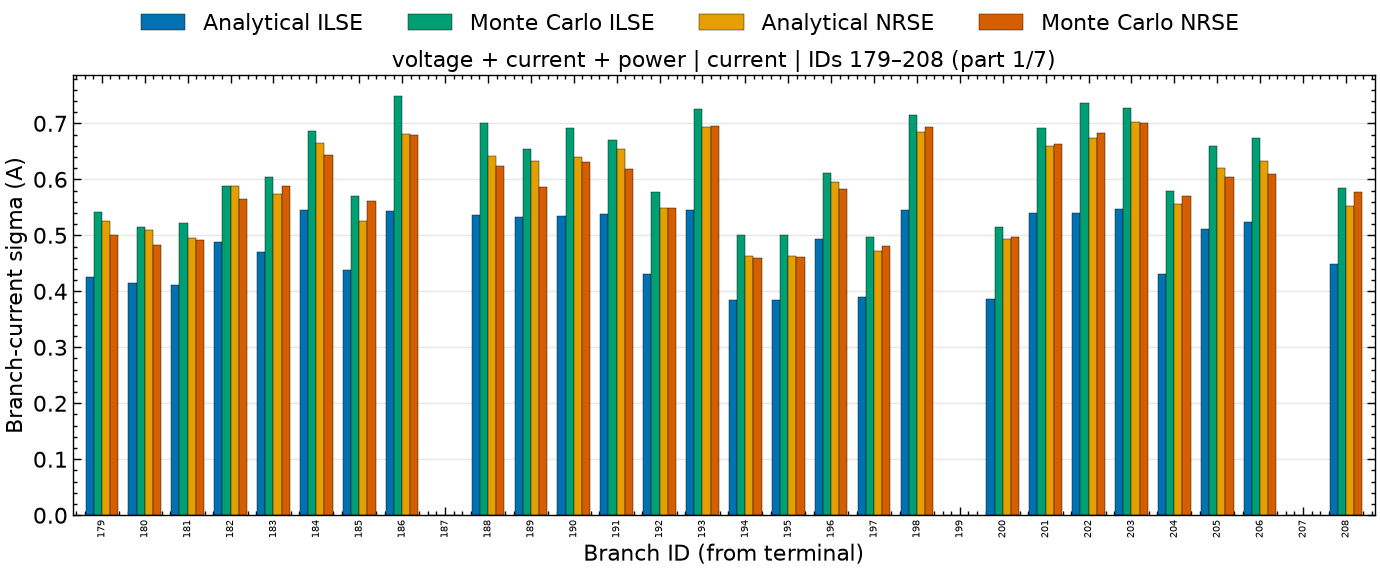

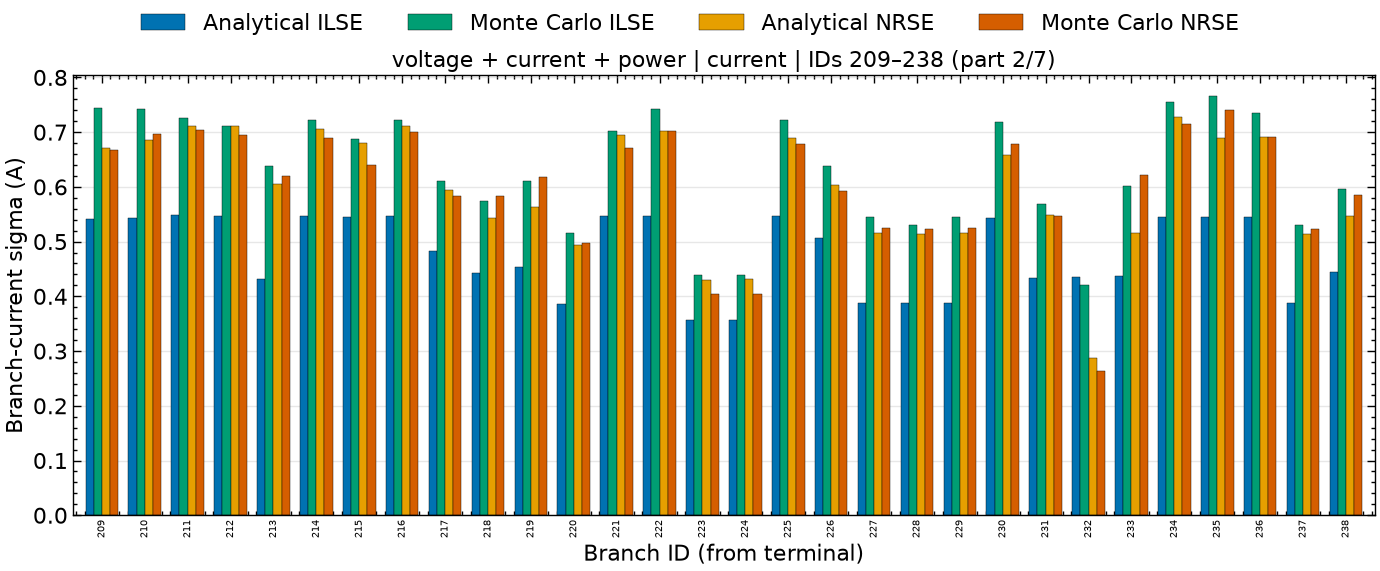

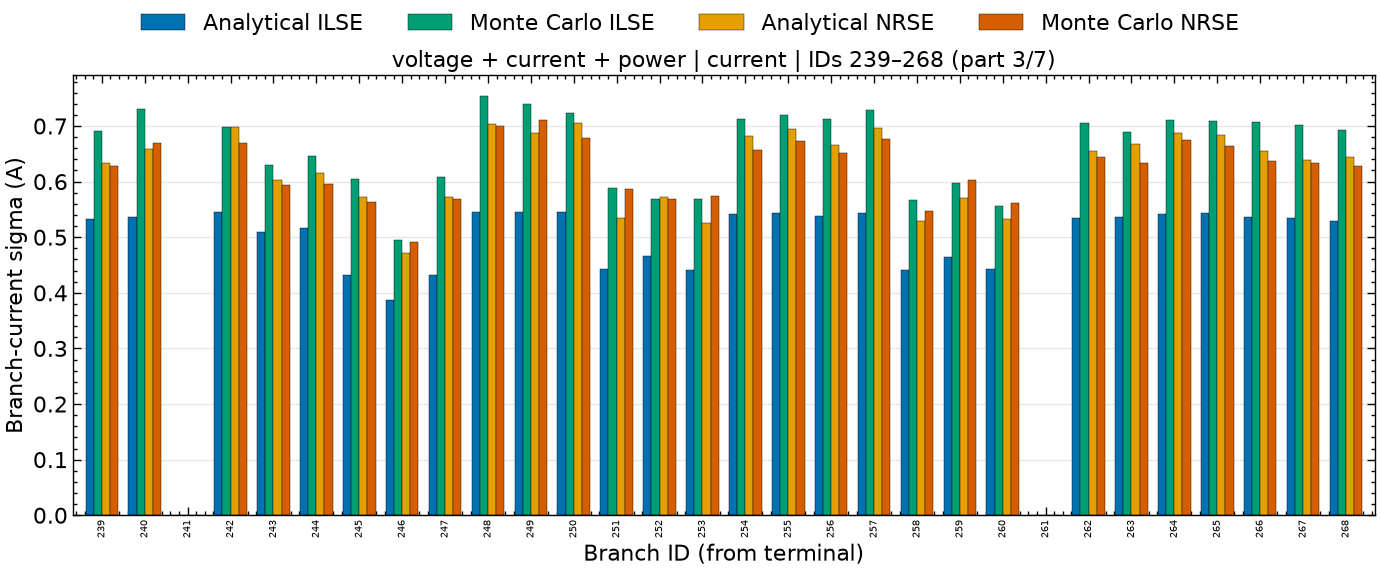

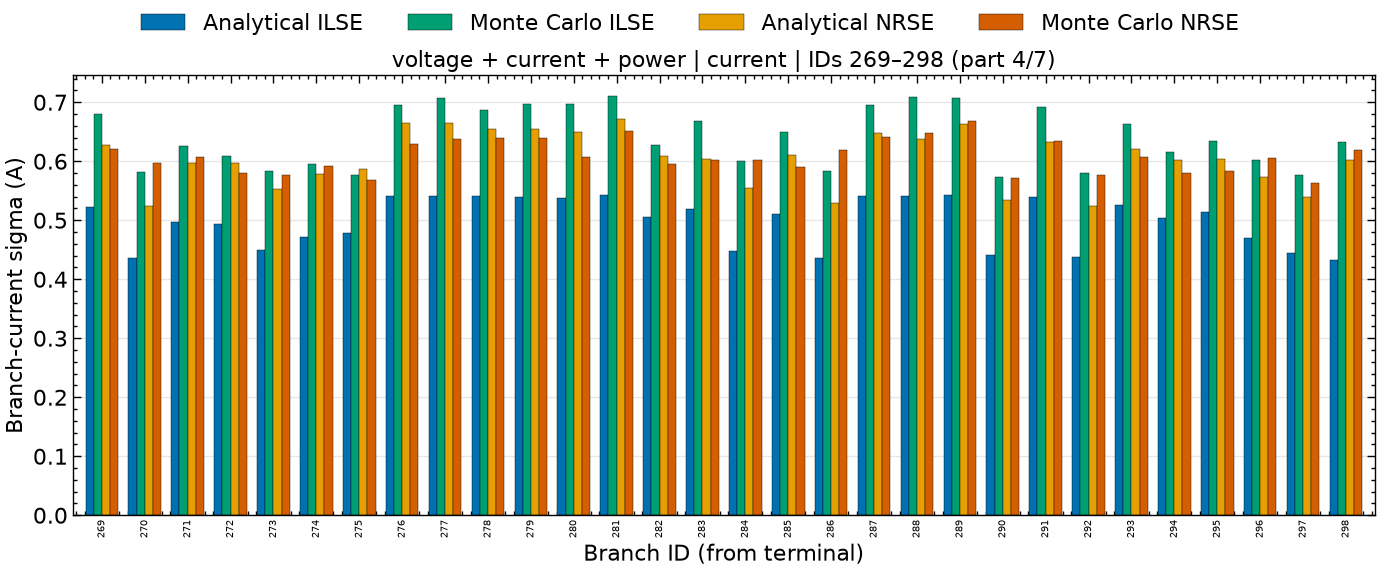

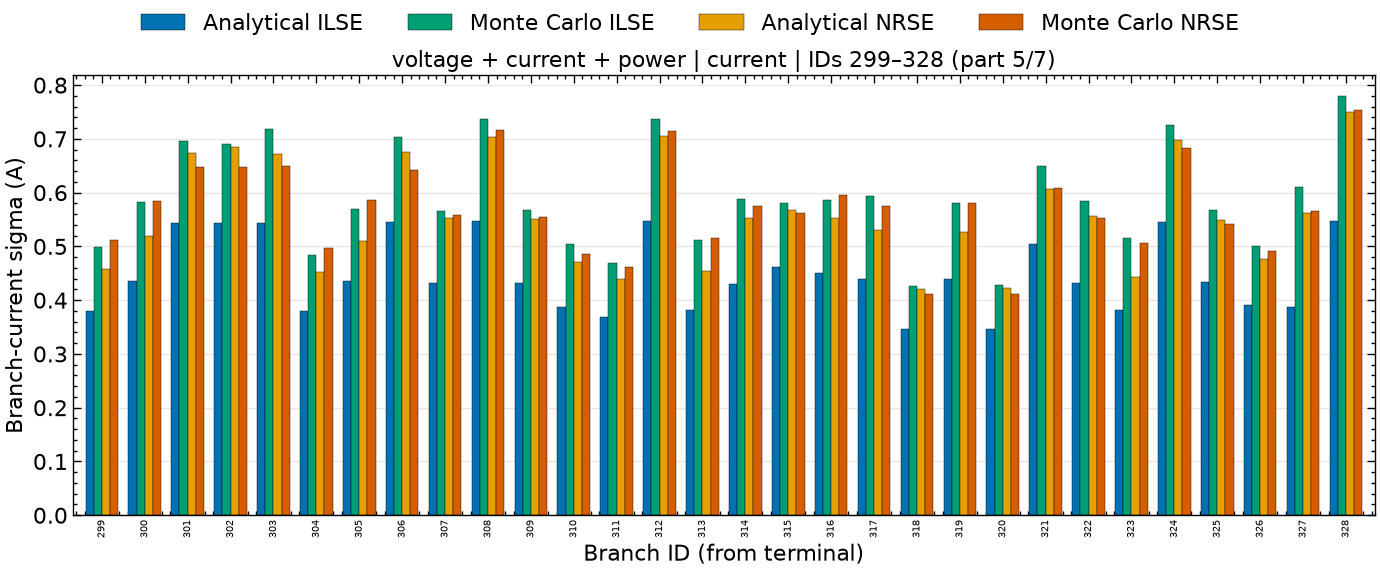

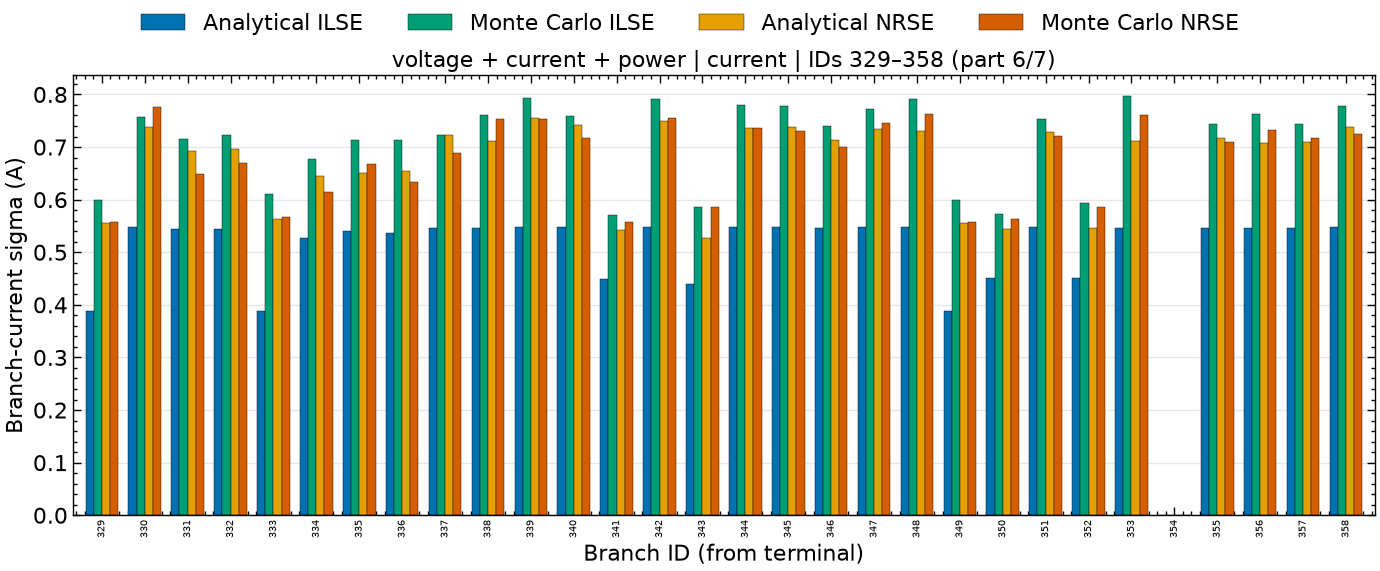

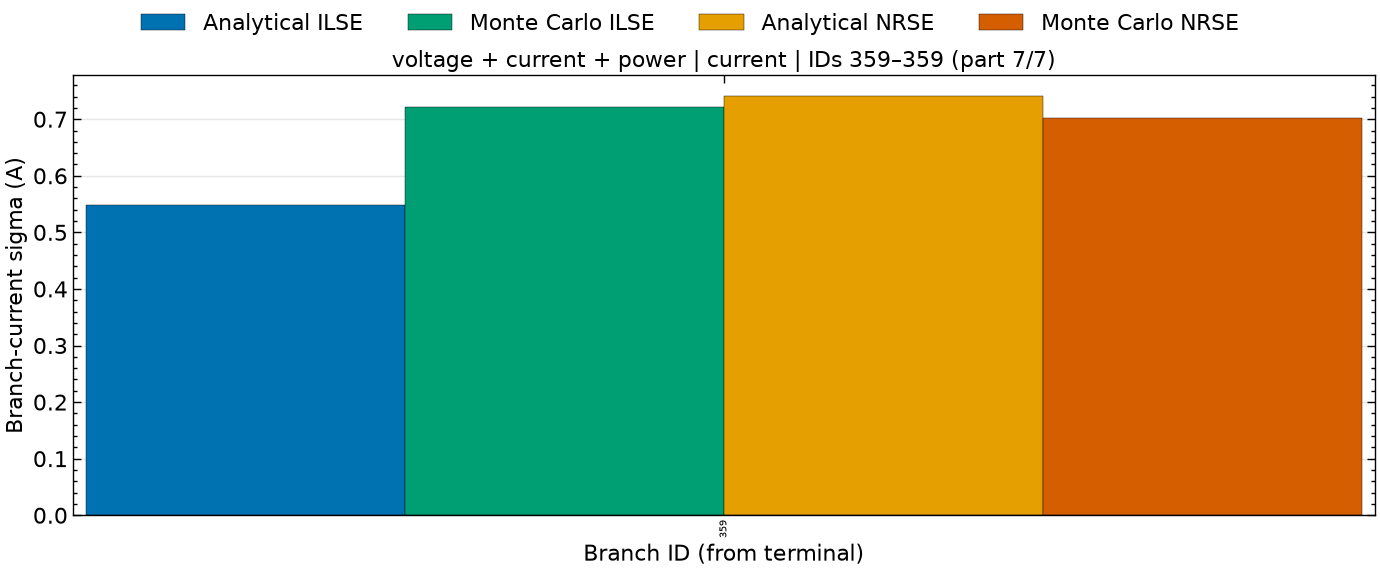

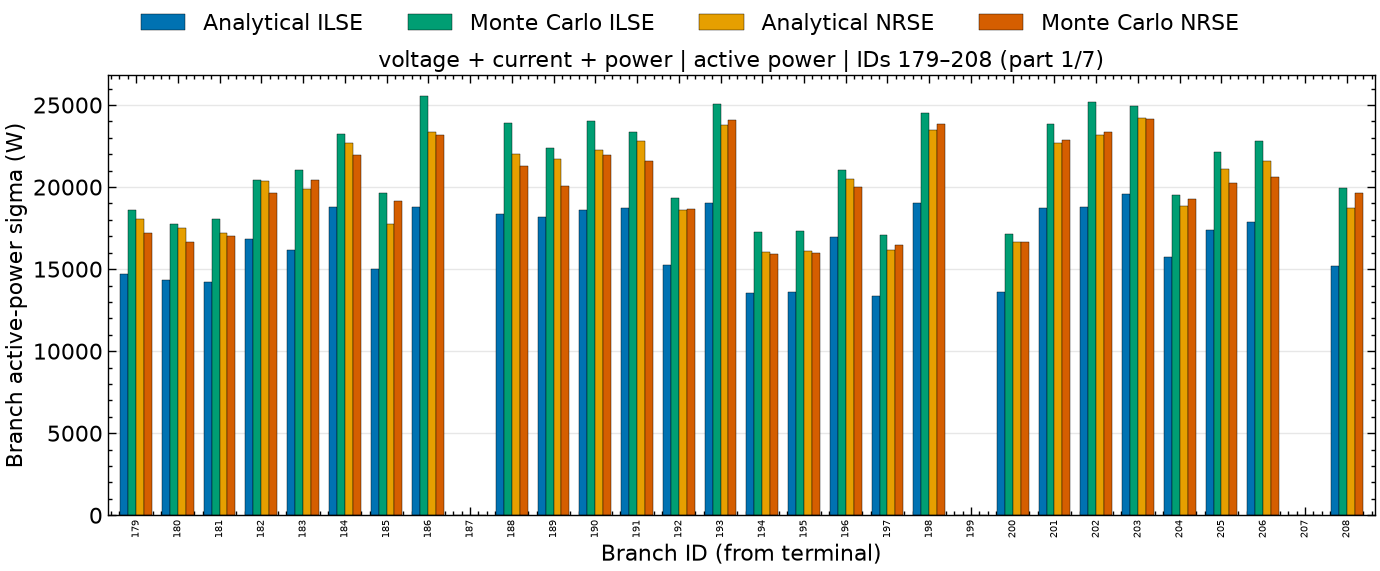

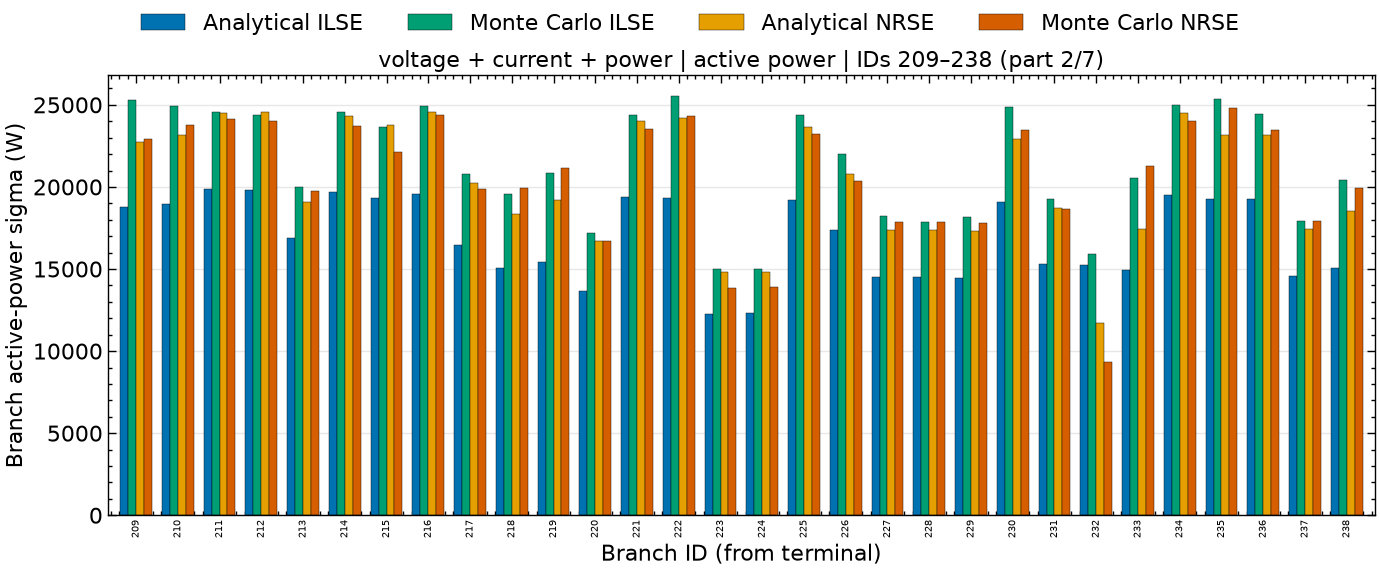

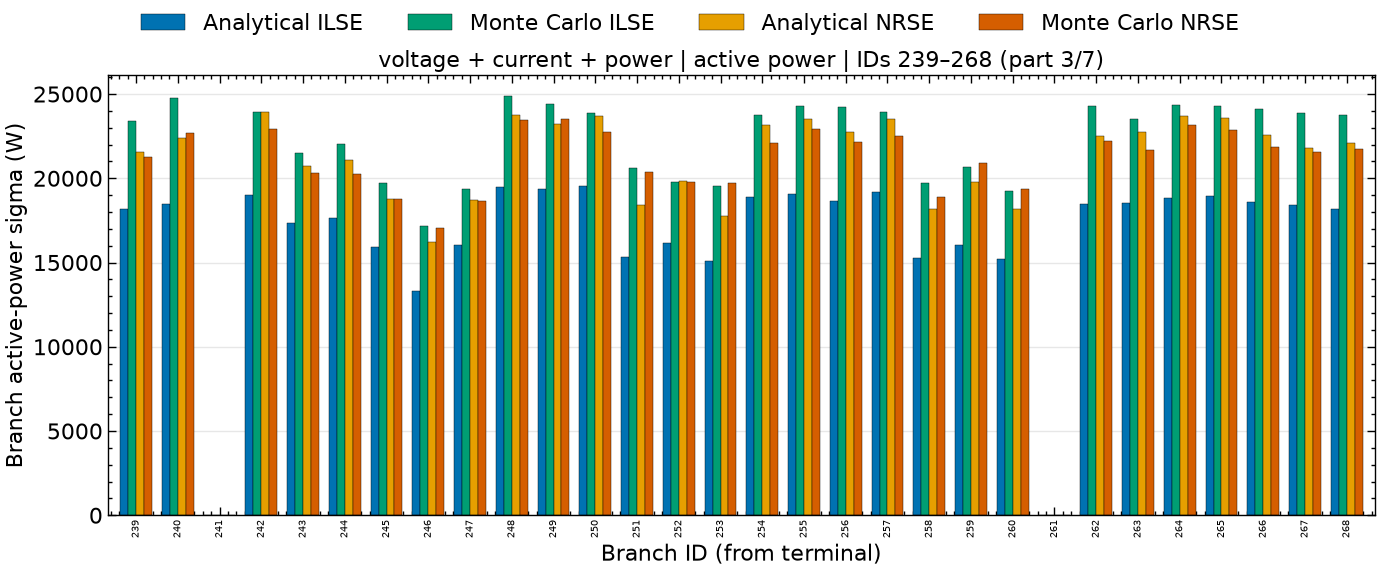

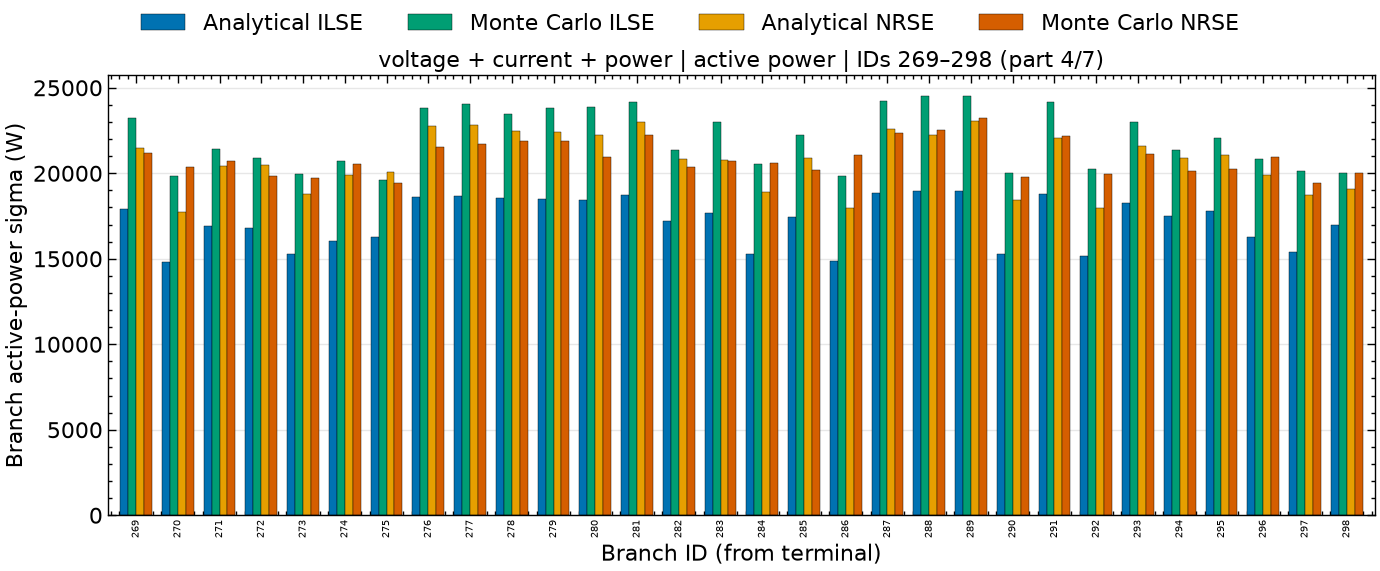

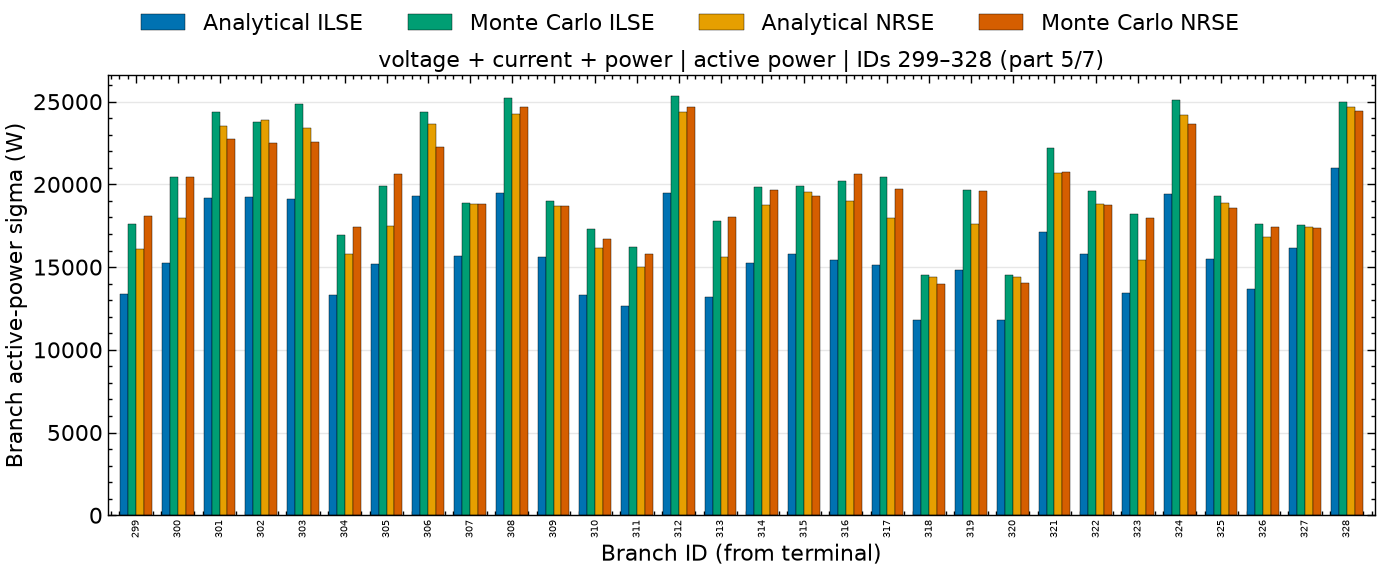

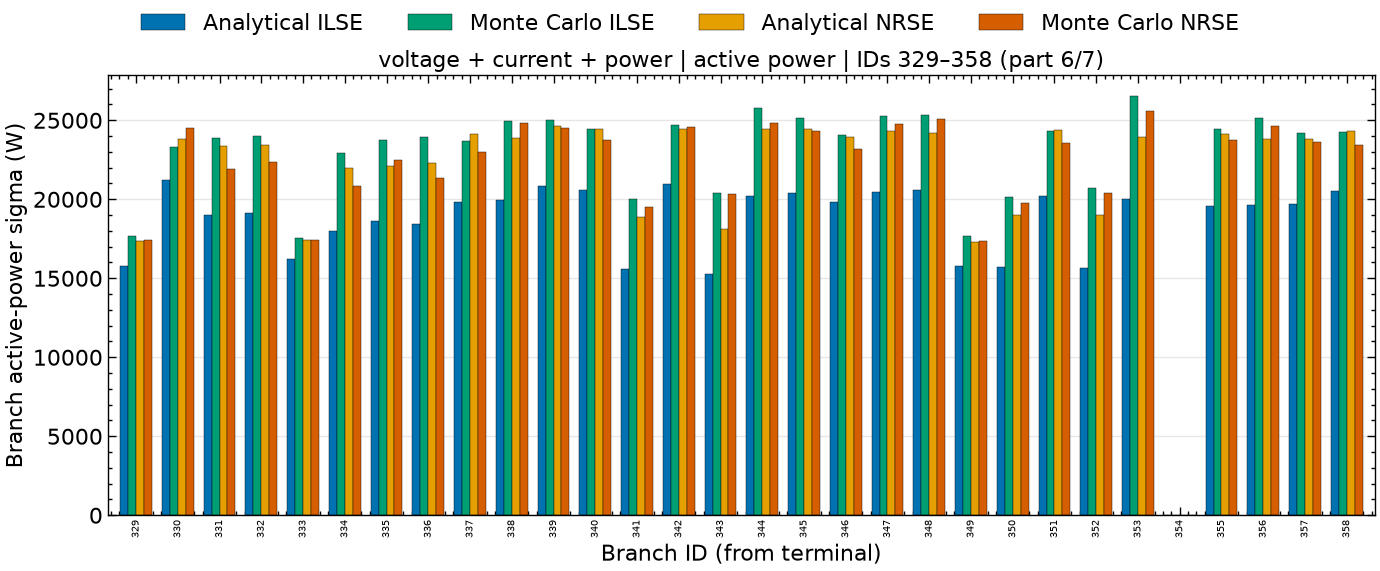

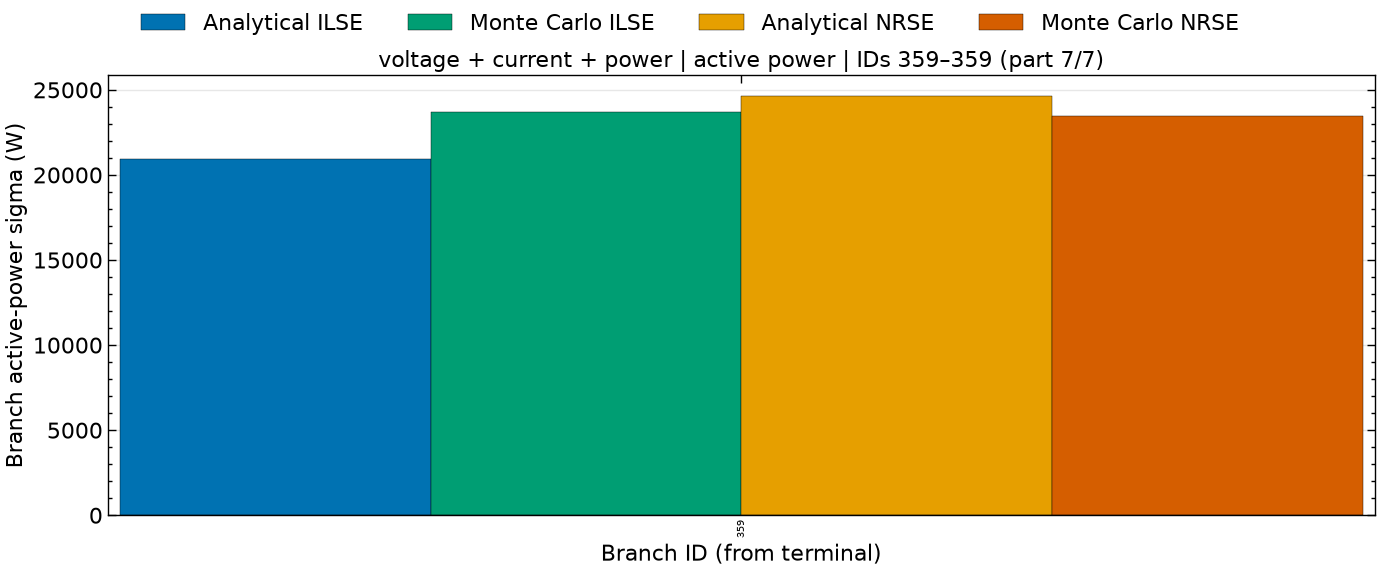

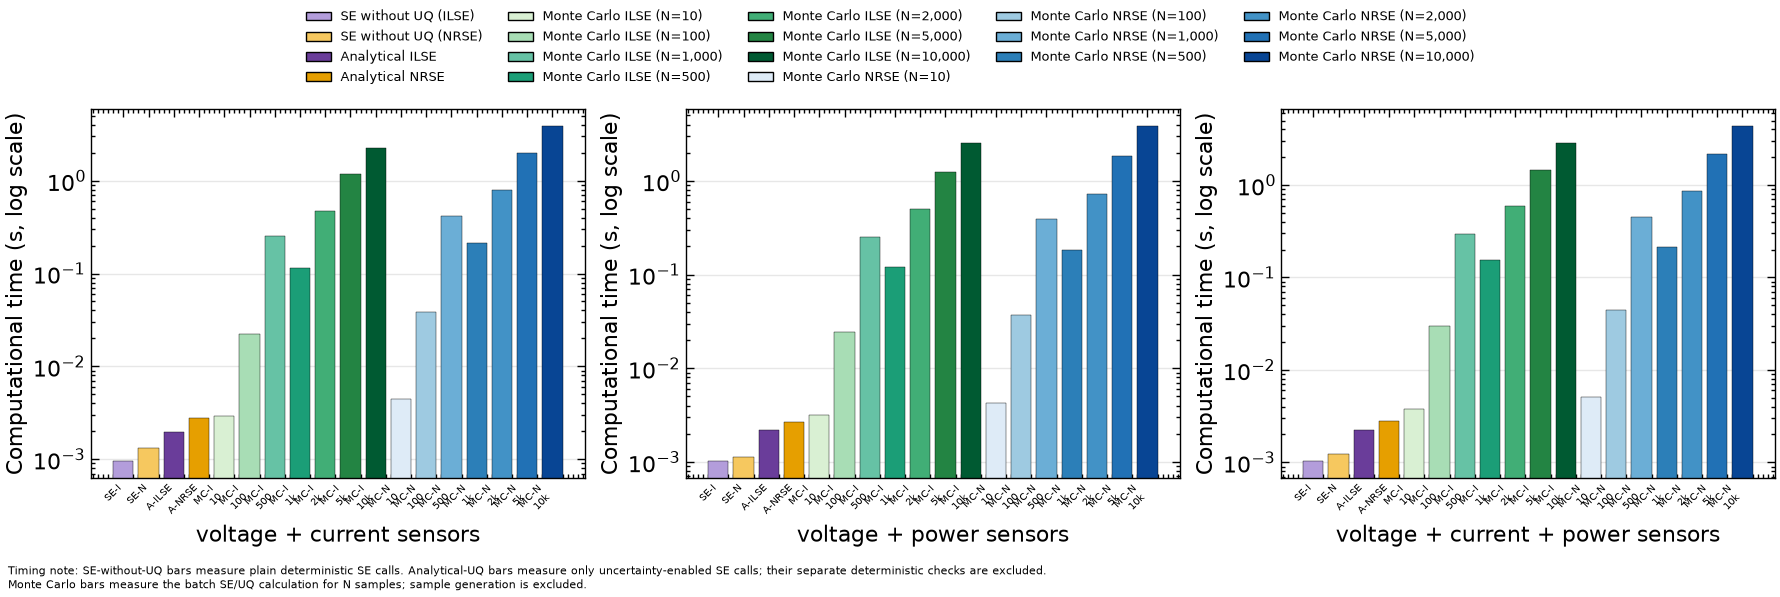

In [8]:
# ruff: noqa: E501
from pathlib import Path

from matplotlib.patches import Patch

try:
    import scienceplots  # noqa: F401
except ImportError:
    plot_style = ["default"]
else:
    plot_style = ["science", "notebook"]

method_columns = [
    ("Analytical ILSE sigma", "Analytical ILSE", "#0072B2"),
    ("Monte Carlo ILSE sigma", "Monte Carlo ILSE", "#009E73"),
    ("Analytical NRSE sigma", "Analytical NRSE", "#E69F00"),
    ("Monte Carlo NRSE sigma", "Monte Carlo NRSE", "#D55E00"),
]
plot_definitions = [
    ("node", "voltage magnitude", "Voltage sigma (V)", "Node ID", None),
    ("line", "current", "Branch-current sigma (A)", "Branch ID (from terminal)", "from"),
    ("line", "active power", "Branch active-power sigma (W)", "Branch ID (from terminal)", "from"),
]


def plot_sigma_bars(ax, filtered, plot_definition):
    _, _, ylabel, xlabel, _ = plot_definition
    positions = np.arange(len(filtered))
    bar_width = 0.19
    offsets = (np.arange(len(method_columns)) - 1.5) * bar_width
    for offset, (column, label, color) in zip(offsets, method_columns, strict=True):
        ax.bar(
            positions + offset,
            filtered[column].to_numpy(),
            width=bar_width,
            label=label,
            color=color,
            edgecolor="black",
            linewidth=0.3,
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(positions)
    ax.set_xticklabels(filtered["id"].astype(str).tolist(), rotation=90, fontsize=7)
    ax.grid(axis="y", visible=True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.margins(x=0.01)


figure_directory = output_directory / "figures"
figure_directory.mkdir(parents=True, exist_ok=True)

node_ids_for_plot = sorted(
    int(node_id) for node_id in base_input_data[ComponentType.node][AttributeType.id]
)
node_index = {node_id: index for index, node_id in enumerate(node_ids_for_plot)}
topology_edges = [
    (int(row[AttributeType.from_node]), int(row[AttributeType.to_node]))
    for row in base_input_data[ComponentType.line]
]
topology_edges.extend(
    (int(row[AttributeType.from_node]), int(row[AttributeType.to_node]))
    for row in base_input_data[ComponentType.transformer]
)
angles = np.linspace(0.0, 2.0 * np.pi, len(node_ids_for_plot), endpoint=False)
topology_coordinates = np.column_stack((np.cos(angles), np.sin(angles)))
for _ in range(180):
    displacement = topology_coordinates[:, None, :] - topology_coordinates[None, :, :]
    distances = np.maximum(np.linalg.norm(displacement, axis=2, keepdims=True), 0.08)
    topology_coordinates += 0.004 * np.sum(displacement / distances**3, axis=1)
    for from_node, to_node in topology_edges:
        from_index = node_index[from_node]
        to_index = node_index[to_node]
        edge_vector = topology_coordinates[to_index] - topology_coordinates[from_index]
        topology_coordinates[from_index] += 0.004 * edge_vector
        topology_coordinates[to_index] -= 0.004 * edge_vector
    topology_coordinates -= topology_coordinates.mean(axis=0)
    topology_coordinates /= max(np.max(np.abs(topology_coordinates)), 1.0)
topology_positions = {
    node_id: topology_coordinates[index]
    for index, node_id in enumerate(node_ids_for_plot)
}
topology_line_rows = {
    int(row[AttributeType.id]): row
    for row in base_input_data[ComponentType.line]
}
topology_transformer_rows = {
    int(row[AttributeType.id]): row
    for row in base_input_data[ComponentType.transformer]
}
network_size_label = (
    f"{len(node_ids_for_plot)} buses, {len(topology_line_rows)} lines, "
    f"{len(topology_transformer_rows)} transformers"
)
with plt.style.context(plot_style), plt.rc_context({"text.usetex": False}):
    topology_figure, topology_axis = plt.subplots(figsize=(14, 9))
    for line_id, row in topology_line_rows.items():
        from_node = int(row[AttributeType.from_node])
        to_node = int(row[AttributeType.to_node])
        x_values = [topology_positions[from_node][0], topology_positions[to_node][0]]
        y_values = [topology_positions[from_node][1], topology_positions[to_node][1]]
        is_closed = bool(row[AttributeType.from_status]) and bool(row[AttributeType.to_status])
        topology_axis.plot(
            x_values,
            y_values,
            color="#0072B2" if is_closed else "#D55E00",
            linestyle="-" if is_closed else "--",
            linewidth=0.8 if is_closed else 2.0,
            alpha=0.65,
        )
        if not is_closed:
            topology_axis.text(
                sum(x_values) / 2,
                sum(y_values) / 2,
                str(line_id),
                color="#991b1b",
                fontsize=7,
                ha="center",
                va="center",
                bbox={"facecolor": "#fde2e1", "edgecolor": "none", "pad": 1.2},
            )
    for row in topology_transformer_rows.values():
        from_node = int(row[AttributeType.from_node])
        to_node = int(row[AttributeType.to_node])
        topology_axis.plot(
            [topology_positions[from_node][0], topology_positions[to_node][0]],
            [topology_positions[from_node][1], topology_positions[to_node][1]],
            color="#7B2CBF",
            linewidth=2.6,
            alpha=0.9,
        )
    topology_axis.scatter(
        [topology_positions[node_id][0] for node_id in node_ids_for_plot],
        [topology_positions[node_id][1] for node_id in node_ids_for_plot],
        s=20,
        color="#E69F00",
        edgecolor="black",
        linewidth=0.25,
        zorder=3,
    )
    topology_axis.set_title(f"MV Oberrhein topology ({network_size_label})", pad=12)
    topology_axis.axis("off")
    topology_axis.legend(
        handles=[
            plt.Line2D([0], [0], color="#0072B2", linewidth=1.4, label="Closed line"),
            plt.Line2D([0], [0], color="#D55E00", linestyle="--", linewidth=2.0, label="Open sectioning line"),
            plt.Line2D([0], [0], color="#7B2CBF", linewidth=2.6, label="Transformer"),
        ],
        loc="upper right",
    )
    topology_figure.tight_layout()
    topology_figure.savefig(figure_directory / "mv_oberrhein_topology.pdf")
    topology_figure.savefig(figure_directory / "mv_oberrhein_topology.png", dpi=300)
    plt.show()
setting_slugs = {
    "voltage + current": "voltage_current",
    "voltage + power": "voltage_power",
    "voltage + current + power": "voltage_current_power",
}
plot_chunk_size = 30

with plt.style.context(plot_style), plt.rc_context({"text.usetex": False}):
    for setting in sensor_settings:
        for plot_definition in plot_definitions:
            component, quantity, _, _, terminal = plot_definition
            filtered = comparison[
                (comparison["sensor setting"] == setting)
                & (comparison["component"] == component)
                & (comparison["quantity"] == quantity)
            ].copy()
            if terminal is not None:
                filtered = filtered[filtered["terminal"] == terminal]
            filtered = filtered.sort_values("id").reset_index(drop=True)
            chunk_count = (len(filtered) + plot_chunk_size - 1) // plot_chunk_size
            quantity_slug = quantity.replace(" ", "_")
            for chunk_number, chunk_start in enumerate(
                range(0, len(filtered), plot_chunk_size),
                start=1,
            ):
                chunk = filtered.iloc[chunk_start : chunk_start + plot_chunk_size]
                chunk_end = chunk_start + len(chunk)
                figure, axis = plt.subplots(figsize=(14, 6))
                plot_sigma_bars(axis, chunk, plot_definition)
                axis.set_title(
                    f"{setting} | {quantity} | IDs {int(chunk['id'].iloc[0])}–{int(chunk['id'].iloc[-1])} "
                    f"(part {chunk_number}/{chunk_count})"
                )
                handles, labels = axis.get_legend_handles_labels()
                figure.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 0.98))
                figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.91))
                figure_path = figure_directory / (
                    f"mv_oberrhein_{setting_slugs[setting]}_{component}_{quantity_slug}_part_{chunk_number:02d}"
                )
                figure.savefig(figure_path.with_suffix(".pdf"))
                figure.savefig(figure_path.with_suffix(".png"), dpi=300)
                plt.show()
                plt.close(figure)

monte_carlo_baseline_sample_count = 1_000
timing_sample_counts = [*monte_carlo_timing_sample_counts[:2], monte_carlo_baseline_sample_count, *monte_carlo_timing_sample_counts[2:]]
timing_sample_labels = dict(zip(timing_sample_counts, ["10", "100", "500", "1k", "2k", "5k", "10k"], strict=True))
timing_ilse_colors = ["#D9F0D3", "#A8DDB5", "#66C2A5", "#1B9E77", "#41AE76", "#238443", "#005A32"]
timing_nrse_colors = ["#DEEBF7", "#9ECAE1", "#6BAED6", "#2C7FB8", "#4292C6", "#2171B5", "#084594"]
timing_method_columns = [
    ("SE without UQ (ILSE)", "SE-I", "#B39DDB"),
    ("SE without UQ (NRSE)", "SE-N", "#F6C85F"),
    ("Analytical ILSE", "A-ILSE", "#6A3D9A"),
    ("Analytical NRSE", "A-NRSE", "#E69F00"),
] + [
    (f"Monte Carlo ILSE (N={sample_count:,})", f"MC-I\n{timing_sample_labels[sample_count]}", color)
    for sample_count, color in zip(timing_sample_counts, timing_ilse_colors, strict=True)
] + [
    (f"Monte Carlo NRSE (N={sample_count:,})", f"MC-N\n{timing_sample_labels[sample_count]}", color)
    for sample_count, color in zip(timing_sample_counts, timing_nrse_colors, strict=True)
]

with plt.style.context(plot_style), plt.rc_context({"text.usetex": False}):
    timing_figure, timing_axes = plt.subplots(1, 3, figsize=(18, 6))
    for axis, setting in zip(timing_axes, sensor_settings, strict=True):
        values = [
            deterministic_seconds[setting, "Analytical ILSE"],
            deterministic_seconds[setting, "Analytical NRSE"],
            analytical_seconds[setting, "Analytical ILSE"],
            analytical_seconds[setting, "Analytical NRSE"],
            *[
                monte_carlo_seconds[setting, "Analytical ILSE"]
                if sample_count == monte_carlo_baseline_sample_count
                else monte_carlo_scaling_seconds[setting, "Analytical ILSE", sample_count]
                for sample_count in timing_sample_counts
            ],
            *[
                monte_carlo_seconds[setting, "Analytical NRSE"]
                if sample_count == monte_carlo_baseline_sample_count
                else monte_carlo_scaling_seconds[setting, "Analytical NRSE", sample_count]
                for sample_count in timing_sample_counts
            ],
        ]
        labels = [label for _, label, _ in timing_method_columns]
        colors = [color for _, _, color in timing_method_columns]
        axis.bar(np.arange(len(values)), values, color=colors, edgecolor="black", linewidth=0.3)
        axis.set_xlabel(f"{setting} sensors")
        axis.set_ylabel("Computational time (s, log scale)")
        axis.set_yscale("log")
        axis.set_xticks(np.arange(len(values)))
        axis.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
        axis.grid(axis="y", visible=True, alpha=0.3)
        axis.set_axisbelow(True)
    timing_legend_handles = [
        Patch(facecolor=color, edgecolor="black", label=method_name)
        for method_name, _, color in timing_method_columns
    ]
    timing_figure.legend(
        handles=timing_legend_handles,
        loc="upper center",
        ncol=5,
        fontsize=9,
        bbox_to_anchor=(0.5, 1.0),
    )
    timing_figure.text(
        0.01,
        0.01,
        "Timing note: SE-without-UQ bars measure plain deterministic SE calls. Analytical-UQ bars measure only uncertainty-enabled SE calls; their separate deterministic checks are excluded.\nMonte Carlo bars measure the batch SE/UQ calculation for N samples; sample generation is excluded.",
        ha="left",
        va="bottom",
        fontsize=8,
    )
    timing_figure.tight_layout(rect=(0.0, 0.06, 1.0, 0.84))
    timing_figure.savefig(figure_directory / "mv_oberrhein_uq_computational_time.pdf")
    timing_figure.savefig(figure_directory / "mv_oberrhein_uq_computational_time.png", dpi=300)
    plt.show()

## Interpretation

The sensor layout changes both observability and the covariance model. Analytical ILSE and NRSE are method-specific first-order approximations, while Monte Carlo includes the nonlinear estimator response and the public sensor-coordinate sampling. The Monte Carlo columns therefore provide an empirical comparison rather than an exact equality test against every analytical column.

Increase `monte_carlo_sample_count` for tighter empirical estimates, or replace `output_specs` to inspect other nodes, branches, or output quantities.